# Probability, Bayes Rule and the MAP Classifier: Solutions to the Exercises

### Companion notebook to *Probability on Data: Joint, Marginal, Conditional, Priors, Bayes Rule and a MAP Classifier*

Worked solutions to the four exercises at the end of the main notebook.

> **Attempt each exercise yourself before reading its solution.** Two of these produce a result that
> is not the one most people predict, and the value comes from being surprised by your own run first.
> Reading the answer cold turns a genuine insight into a fact to be memorised.

Each solution is laid out the same way:

1. **What is really being tested**: the idea behind the question, which is usually not the same as
   the task it asks you to perform
2. **The solution**: written with the same tools as the main notebook, plain NumPy and pandas, with a
   **Line by line** commentary under every code cell
3. **What to observe**: how to read the output, and what a complete written answer should say

Where a result contradicts the obvious expectation, the explanation of **why** is the actual answer.
Being able to explain a surprising result is worth far more than remembering a rule.

---

## Contents

| Exercise | Topic | Core idea being tested |
|---|---|---|
| 1 | A joint distribution of your own | Which axis you normalise over decides which conditional you get |
| 2 | Bayes rule with a new piece of evidence | Sequential updating, and why a false positive rate dominates |
| 3 | Changing the classifier's feature set | Redundant features break conditional independence |
| 4 | The prior, the boundary, and class imbalance | Variances control curvature, the prior controls the threshold |

## Requirements

```
uv add numpy pandas matplotlib
```

Same three libraries as the main notebook. Nothing extra is needed, and nothing is downloaded.

## Reproducing these numbers

Section 0 below rebuilds the whole state of the main notebook from scratch, in the same order and
from the same seed, so every number printed here is **identical** to the number printed there. The
random generator is consumed in exactly two places, the data generation and the train test split, so
as long as you run this notebook top to bottom you will see the same output.

If you change the seed the third decimal place will move, but every **pattern** discussed below is
stable. Read the direction and size of each difference rather than the exact digits.

## 0. Setup

This notebook runs on its own. The cells in this section recreate exactly the objects the exercises
refer to, so the main notebook does not need to be executed first.

Nothing here is new material. If you have the main notebook open and already executed you can skip
straight to Exercise 1, but running these cells costs a second and guarantees the numbers match.

In [1]:
import numpy as np                      # arrays, random sampling, all the numerical work
import pandas as pd                     # tables, so distributions print with readable labels
import matplotlib.pyplot as plt         # every plot in this notebook

%matplotlib inline

rng = np.random.default_rng(7)          # the SAME seed as the main notebook: identical numbers
np.set_printoptions(precision=3, suppress=True)   # 3 decimals, no scientific notation
pd.set_option("display.precision", 3)             # same idea for DataFrames
plt.rcParams["figure.figsize"] = (6, 4)           # default plot size in inches
plt.rcParams["figure.dpi"] = 110                  # default resolution

print("numpy :", np.__version__)
print("pandas:", pd.__version__)

numpy : 2.5.2
pandas: 3.0.5


**Line by line**

- `np.random.default_rng(7)`: the seed is the single most important line in this notebook. The main
  notebook used `7`, so using `7` here reproduces the same 400 apartments, the same train test split
  and therefore the same accuracy figures. Change it and every number below shifts.
- `np.set_printoptions(precision=3, suppress=True)`: display only, it changes nothing that is
  computed. `suppress=True` prints `0.001` instead of `1.000e-03`, which matters because
  probabilities are often small.
- The two `plt.rcParams` lines set a default size and sharpness for every figure, so no plotting cell
  below has to repeat them.
- Printing the library versions is a habit worth keeping in any notebook you will hand to someone
  else: if their output differs from yours, the version is the first thing to check.

In [2]:
N = 400                                            # number of apartments to generate

DISTRICTS = ["center", "suburb", "industrial"]     # the vocabulary of the categorical feature
CLASS_NAMES = ["affordable", "expensive"]          # class 0 and class 1, in index order

TRUE_PRIOR = np.array([0.65, 0.35])                # P(C=0), P(C=1): the true prior

TRUE_P_DISTRICT = {                                # P(district | C), one row per class
    0: np.array([0.15, 0.45, 0.40]),               # affordable: mostly suburb/industrial
    1: np.array([0.60, 0.30, 0.10]),               # expensive : mostly center
}

TRUE_AREA = {0: (65.0, 18.0), 1: (105.0, 22.0)}    # (mean, std) of area_m2 given each class
TRUE_AGE = {0: (22.0, 12.0), 1: (8.0, 6.0)}        # (mean, std) of age_yrs given each class

labels = rng.choice([0, 1], size=N, p=TRUE_PRIOR)  # step 1: draw N class labels from the prior

area = np.empty(N)                                 # empty containers to fill in class by class
age = np.empty(N)
district = np.empty(N, dtype=object)               # dtype=object because these are Python strings

for c in (0, 1):                                   # handle one class at a time
    mask = labels == c                             # boolean array: True where the label equals c
    k = int(mask.sum())                            # how many apartments fall in this class
    mu_a, sd_a = TRUE_AREA[c]                      # unpack that class's area parameters
    mu_g, sd_g = TRUE_AGE[c]                       # unpack that class's age parameters
    area[mask] = rng.normal(mu_a, sd_a, size=k)    # step 3: k Gaussian draws written into those slots
    age[mask] = rng.normal(mu_g, sd_g, size=k)     # step 4: same for age
    district[mask] = rng.choice(DISTRICTS, size=k, p=TRUE_P_DISTRICT[c])   # step 2

area = np.clip(area, 25, None).round(1)            # no apartment smaller than 25 m2; 1 decimal
age = np.clip(age, 0, None).round(0)               # no negative ages; whole years

df = pd.DataFrame({                                # assemble everything into one table
    "area_m2": area,
    "age_yrs": age,
    "district": pd.Categorical(district, categories=DISTRICTS),   # fixes the column order
    "expensive": labels,
})

SIZE_CLASSES = ["small", "medium", "large"]        # the binned version of area_m2
df["size_class"] = pd.cut(df["area_m2"],           # (0,60] small, (60,95] medium, (95,inf) large
                          bins=[0, 60, 95, np.inf],
                          labels=SIZE_CLASSES)

print("dataset shape:", df.shape)                  # (rows, columns) = (400, 5)
df.head(6)

dataset shape: (400, 5)


,area_m2,age_yrs,district,expensive,size_class
0,39.0,19.0,suburb,0,small
1,156.5,9.0,center,1,large
2,86.3,9.0,center,1,medium
3,79.3,35.0,center,0,medium
4,61.6,11.0,suburb,0,medium
5,102.3,5.0,center,1,large


**Line by line**

- This is the generation cell from Part 0 of the main notebook, reproduced unchanged so that the
  random stream is consumed in exactly the same order. **The order matters as much as the seed.**
  Adding a single extra `rng` call anywhere above would shift every draw that follows it and quietly
  change all the numbers.
- `rng.choice([0, 1], size=N, p=TRUE_PRIOR)`: draws `N` class labels from the prior. This one line is
  step 1 of the generative story, "sample the class", repeated 400 times.
- `mask = labels == c`: a boolean array of 400 `True`/`False` values, not a number.
  `area[mask] = ...` writes only into the positions where the mask is `True`, which is how each class
  gets its own parameters without looping over the 400 rows.
- `rng.normal(mu, sd, size=k)`: `k` draws from the class conditional Gaussian
  $P(\text{area} \mid C = c)$, the distribution the classifier will later have to estimate.
- `np.clip(area, 25, None)`: floors the values at 25 and leaves the top open. The same clip on `age`
  at 0 is what produces the small spike at age zero discussed in Part 4c of the main notebook.
- `pd.Categorical(district, categories=DISTRICTS)`: stores the strings with a **fixed** category
  order, so pandas never re-sorts them alphabetically behind your back. Order discipline is what lets
  index `0` always mean `center`.
- `pd.cut(..., bins=[0, 60, 95, np.inf], labels=SIZE_CLASSES)`: bins the continuous area into three
  named categories. The intervals are half open on the left, written `(left, right]`, so exactly
  60.0 m² is `small` and 60.1 m² is `medium`. `np.inf` as the final edge guarantees no row falls
  outside the bins and becomes `NaN`.

In [3]:
def gaussian_pdf(x, mu, sigma):
    '''Probability density of N(mu, sigma^2), evaluated elementwise at x.'''
    norm_const = 1.0 / np.sqrt(2.0 * np.pi * sigma ** 2)    # the 1/sqrt(2 pi sigma^2) factor
    exponent = -((x - mu) ** 2) / (2.0 * sigma ** 2)        # the -(x-mu)^2 / (2 sigma^2) term
    return norm_const * np.exp(exponent)                    # multiply them: the density


def log_gaussian_pdf(x, mu, sigma):
    '''log of the Gaussian density, with the log taken analytically so nothing underflows.'''
    return -0.5 * np.log(2.0 * np.pi * sigma ** 2) - ((x - mu) ** 2) / (2.0 * sigma ** 2)


def bayes_posterior(prior, likelihood):
    '''Posterior over hypotheses given a prior vector and a likelihood vector for the evidence seen.

    prior      : (k,) array, P(H_i), must sum to 1
    likelihood : (k,) array, P(evidence | H_i) for the ONE evidence value that was observed
    returns    : (k,) posterior array P(H_i | evidence), sums to 1
    '''
    unnormalised = prior * likelihood              # elementwise: P(e | H_i) P(H_i), the joint P(H_i, e)
    evidence = unnormalised.sum()                  # P(e) = sum over hypotheses: the normaliser
    return unnormalised / evidence                 # divide so the posterior sums to 1


def log_scores_to_posterior(scores):
    '''Turn un-normalised log scores into a proper posterior, using the log-sum-exp trick.'''
    shifted = scores - scores.max(axis=1, keepdims=True)     # largest entry per row becomes 0
    unnormalised = np.exp(shifted)                           # safe: no exponent is ever positive
    return unnormalised / unnormalised.sum(axis=1, keepdims=True)   # rows now sum to 1


print("sanity check, the two Gaussian forms agree:",
      np.allclose(np.log(gaussian_pdf(np.array([50.0, 90.0]), 100.0, 20.0)),
                  log_gaussian_pdf(np.array([50.0, 90.0]), 100.0, 20.0)))

sanity check, the two Gaussian forms agree: True


**Line by line**

- `gaussian_pdf`: the density formula split into two named pieces. Writing `norm_const` and
  `exponent` separately is purely for readability, since the one line version is much harder to check
  against the printed maths.
- `np.exp` rather than `math.exp`, so the function evaluates on a whole array of `x` values at once.
  That vectorisation is what lets one call cover 400 grid points.
- `log_gaussian_pdf`: the log is taken **analytically**, not by calling `np.log` on the density.
  Taking the log of the formula turns the `exp` into nothing and the leading fraction into a
  subtraction, so the tiny number is never formed in the first place. Writing
  `np.log(gaussian_pdf(...))` would compute the underflowing quantity and only then try to rescue it,
  which is too late.
- `bayes_posterior`: `prior * likelihood` is a single `*`, elementwise, **not** `@`. Each hypothesis
  is scored independently, so there is nothing to sum across hypotheses at that stage.
  `unnormalised.sum()` then marginalises the hypothesis away and produces the evidence $P(e)$, which
  is computed rather than supplied.
- `log_scores_to_posterior`: subtracting the row maximum makes the largest exponent exactly `0`, so
  `np.exp` can never overflow, and the constant cancels between numerator and denominator so the
  ratio is untouched. This is the log-sum-exp trick.
- `keepdims=True`: returns shape `(n, 1)` instead of `(n,)`, a column that broadcasts across the row.
  Without it the division would line the wrong axes up.

In [4]:
joint_counts = np.zeros((len(DISTRICTS), len(SIZE_CLASSES)))      # a 3x3 grid of zeros to fill

for i, d_value in enumerate(DISTRICTS):                           # i indexes rows (district)
    for j, s_value in enumerate(SIZE_CLASSES):                    # j indexes columns (size)
        both_true = (df["district"] == d_value) & (df["size_class"] == s_value)
        joint_counts[i, j] = both_true.sum()                      # how many rows satisfy BOTH

joint = joint_counts / joint_counts.sum()          # divide by the grand total to get probabilities

marg_district = joint.sum(axis=1)                  # sum ACROSS columns -> one number per row
marg_size = joint.sum(axis=0)                      # sum DOWN rows      -> one number per column

print("P(district, size_class):")
print(pd.DataFrame(joint, index=DISTRICTS, columns=SIZE_CLASSES).round(3))
print("\nP(district)  :", marg_district.round(3))
print("P(size_class):", marg_size.round(3))

P(district, size_class):
            small  medium  large
center      0.055   0.122  0.158
suburb      0.118   0.192  0.088
industrial  0.108   0.142  0.018

P(district)  : [0.335 0.397 0.268]
P(size_class): [0.28  0.458 0.262]


**Line by line**

- The double loop is the joint counting pattern from Part 2a. The `&` inside is the entire difference
  between a joint and a marginal probability: it requires both events at once instead of one at a
  time.
- `joint_counts / joint_counts.sum()`: dividing by the **grand** total, not by row or column totals,
  is what makes this a joint distribution rather than a conditional one.
- `joint.sum(axis=1)`: **`axis` names the dimension that disappears.** `axis=1` is the column axis, so
  the columns are consumed and one number survives per row, giving `P(district)`.
- `marg_district` is the object Exercise 1 step 3 asks you to check your own district marginal
  against, which is why it is rebuilt here.

In [5]:
joint_dc_counts = np.zeros((2, len(DISTRICTS)))    # rows = class (0, 1), columns = district

for c in (0, 1):
    for j, d_value in enumerate(DISTRICTS):
        joint_dc_counts[c, j] = np.sum((df["expensive"] == c) & (df["district"] == d_value))

joint_dc = joint_dc_counts / joint_dc_counts.sum()             # joint P(class, district), sums to 1

prior_class = joint_dc.sum(axis=1)                             # marginalise district away: P(class)
marg_district_2 = joint_dc.sum(axis=0)                         # marginalise class away:    P(district)

likelihood_d_given_c = joint_dc / prior_class[:, None]         # P(district | class): rows sum to 1

print("prior P(class)      :", prior_class.round(3))
print("marginal P(district):", marg_district_2.round(3))
print("\nlikelihood P(district | class):")
print(pd.DataFrame(likelihood_d_given_c, index=CLASS_NAMES, columns=DISTRICTS).round(3))

prior P(class)      : [0.64 0.36]
marginal P(district): [0.335 0.397 0.268]

likelihood P(district | class):
            center  suburb  industrial
affordable   0.168   0.449       0.383
expensive    0.632   0.306       0.062


**Line by line**

- Same joint counting pattern, now over `(class, district)`. This is the table Part 3c built and the
  one Exercise 2 step 4 reaches back for.
- `joint_dc.sum(axis=1)`: summing away the district leaves `P(class)`, which **is** the prior. The
  prior is not an extra assumption smuggled in from outside, it is a marginal of the joint, estimated
  by counting labels.
- `joint_dc / prior_class[:, None]`: `prior_class` has shape `(2,)` and NumPy would broadcast that
  across rows, dividing each column by a different number, which is the wrong operation. Inserting
  `None` turns it into shape `(2, 1)`, a column vector, which broadcasts across columns and divides
  each row by its own class total. **If a conditional table comes out with the wrong axis summing to
  1, this is almost always why.**

In [6]:
n_train = 300                                      # how many of the 400 rows to train on
perm = rng.permutation(len(df))                    # a random ordering of all row indices

train_idx = perm[:n_train]                         # first 300 shuffled indices -> training set
test_idx = perm[n_train:]                          # remaining 100              -> test set

train = df.iloc[train_idx].reset_index(drop=True)  # .iloc selects rows by integer position
test = df.iloc[test_idx].reset_index(drop=True)

y_train = train["expensive"].to_numpy()            # (300,) labels: 0 or 1
y_test = test["expensive"].to_numpy()              # (100,)

CONT_FEATURES = ["area_m2", "age_yrs"]             # the two continuous features
Xc_train = train[CONT_FEATURES].to_numpy()         # (300, 2) continuous design matrix
Xc_test = test[CONT_FEATURES].to_numpy()           # (100, 2)

d_train = train["district"].to_numpy()             # (300,) categorical feature as strings
d_test = test["district"].to_numpy()               # (100,)

s_train = train["size_class"].to_numpy()           # (300,) the binned area, needed in Exercise 3
s_test = test["size_class"].to_numpy()             # (100,)

print("train shape:", Xc_train.shape, " test shape:", Xc_test.shape)
print("class balance in train:", np.bincount(y_train) / len(y_train))
print("class balance in test :", np.bincount(y_test) / len(y_test))

train shape: (300, 2)  test shape: (100, 2)
class balance in train: [0.637 0.363]
class balance in test : [0.65 0.35]


**Line by line**

- `rng.permutation(len(df))`: a random shuffle of the integers `0 .. 399`. This is the **second and
  final** call that consumes the random stream before the exercises, which is why everything above it
  had to be reproduced exactly.
- `df.iloc[train_idx]`: `.iloc` selects by integer **position**, `.loc` by index **label**. After a
  shuffle these differ, and position is what we want.
- `.reset_index(drop=True)`: renumbers the rows `0, 1, 2, ...` and discards the scrambled old index,
  so later positional indexing into `train` is not confusing.
- `s_train` and `s_test` are the one pair this solutions notebook adds, because Exercise 3 needs
  `size_class` split the same way as everything else. They come from the same `train` and `test`
  frames, so their rows line up with `y_train` and `y_test` automatically.
- `np.bincount(y_train)`: counts occurrences of each non-negative integer, so entry `0` is the number
  of zeros. The two splits should show similar proportions, and they do.

In [7]:
class_counts = np.array([np.sum(y_train == c) for c in (0, 1)], dtype=float)
prior_hat = class_counts / class_counts.sum()      # count and divide: the estimated prior
log_prior = np.log(prior_hat)                      # stored in logs, used by every score below

ALPHA = 1.0                                        # Laplace smoothing strength

district_counts = np.zeros((2, len(DISTRICTS)))    # rows = class, columns = district
for c in (0, 1):
    for j, d_value in enumerate(DISTRICTS):
        district_counts[c, j] = np.sum((y_train == c) & (d_train == d_value))

lik_district = (district_counts + ALPHA) / (       # smoothed P(district | class)
    district_counts.sum(axis=1, keepdims=True) + ALPHA * len(DISTRICTS)
)
log_lik_district = np.log(lik_district)

means = np.zeros((2, len(CONT_FEATURES)))          # means[c, j] = mean of feature j within class c
stds = np.zeros((2, len(CONT_FEATURES)))           # stds[c, j]  = std  of feature j within class c

for c in (0, 1):
    rows_of_class = Xc_train[y_train == c]         # (n_c, 2): only the rows belonging to class c
    means[c] = rows_of_class.mean(axis=0)          # column means -> one per feature
    stds[c] = rows_of_class.std(axis=0, ddof=0)    # ddof=0 for the maximum-likelihood estimate

print("estimated prior:", prior_hat.round(4), "  (true:", TRUE_PRIOR, ")")
print("\nsmoothed P(district | class):")
print(pd.DataFrame(lik_district, index=CLASS_NAMES, columns=DISTRICTS).round(3))
print("\nclass-conditional means:")
print(pd.DataFrame(means, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("\nclass-conditional standard deviations:")
print(pd.DataFrame(stds, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))

estimated prior: [0.637 0.363]   (true: [0.65 0.35] )

smoothed P(district | class):
            center  suburb  industrial
affordable   0.180   0.464       0.356
expensive    0.634   0.312       0.054

class-conditional means:
            area_m2  age_yrs
affordable    63.06    22.22
expensive    106.28     8.08

class-conditional standard deviations:
            area_m2  age_yrs
affordable    16.08    11.89
expensive     22.42     5.92


**Line by line**

- `np.sum(y_train == c)`: the counting-a-boolean-array pattern. Every discrete probability in both
  notebooks is a count divided by a total, and this is the count half.
- `dtype=float`: so the division is not integer division and so `np.log` behaves predictably.
- `district_counts.sum(axis=1, keepdims=True)`: the row totals, that is how many training rows are in
  each class. `keepdims=True` returns shape `(2, 1)` rather than `(2,)`, which is the same job
  `[:, None]` did above, spelled differently.
- `+ ALPHA` on top and `+ ALPHA * len(DISTRICTS)` on the bottom: the smoothing must be added to the
  denominator once per category, or the row would no longer sum to 1.
- `Xc_train[y_train == c]`: **boolean row selection**. The mask has one entry per row, so this keeps
  every column but only the rows of class `c`.
- `.std(axis=0, ddof=0)`: `axis=0` collapses the row dimension leaving one number per feature, and
  `ddof=0` divides by $n$ rather than $n-1$, giving the maximum likelihood estimate that matches the
  formula in Part 1c.

In [8]:
def joint_log_score(Xc, d_values):
    '''Un-normalised log posterior for every row and every class, using all three features.

    Xc       : (n, 2) continuous features
    d_values : (n,)   district strings
    returns  : (n, 2) array, entry [i, c] = log P(c) + sum_j log P(x_ij | c)
    '''
    n_rows = Xc.shape[0]                                     # how many samples we are scoring
    scores = np.zeros((n_rows, 2))                           # one score per sample per class

    district_index = np.array([DISTRICTS.index(v) for v in d_values])   # strings -> column positions

    for c in (0, 1):                                         # build each class's score separately
        total = np.full(n_rows, log_prior[c])                # start from log P(c): the prior term
        for j in range(len(CONT_FEATURES)):                  # add one continuous feature at a time
            total = total + log_gaussian_pdf(Xc[:, j], means[c, j], stds[c, j])
        total = total + log_lik_district[c][district_index]  # add the discrete feature's log likelihood
        scores[:, c] = total                                 # store this class's column

    return scores


scores_test = joint_log_score(Xc_test, d_test)               # (100, 2) log scores
posterior_test = log_scores_to_posterior(scores_test)        # (100, 2) proper probabilities
pred_test = scores_test.argmax(axis=1)                       # the MAP decision, one per row

accuracy_test = (pred_test == y_test).mean()

print("baseline (always predict the majority class):", max(prior_hat).round(3))
print("MAP test accuracy with all three features   :", accuracy_test.round(3))
print("every posterior row sums to 1               :", np.allclose(posterior_test.sum(axis=1), 1.0))

baseline (always predict the majority class): 0.637
MAP test accuracy with all three features   : 0.93
every posterior row sums to 1               : True


**Line by line**

- `np.full(n_rows, log_prior[c])`: an array filled with the same log prior. Every sample starts from
  the same baseline belief and the features move it from there.
- `total = total + log_gaussian_pdf(...)`: **addition, because we are in log space.** In probability
  space this line would be a multiplication, and it is the naive Bayes factorisation
  $\prod_j P(x_j \mid c)$ applied one feature at a time.
- `log_lik_district[c][district_index]`: **fancy indexing**. `log_lik_district[c]` is a 3-vector of
  log probabilities, and indexing it with an array of 100 positions returns 100 values in one go,
  with no loop. This is the discrete analogue of evaluating a density.
- `scores_test.argmax(axis=1)`: the index of the largest entry in each row, `0` or `1`. **This one
  call is the MAP decision rule.** The evidence $P(x)$ never appears, because it is the same positive
  number for both classes and cannot change which of them is larger.
- The test accuracy of 0.930 against a baseline of 0.637 is the reference point that every variant in
  Exercise 3 and Exercise 4 is compared against. Write it down.

---
# Exercise 1

> The notebook analysed `district` against `size_class`. Do the same analysis for **`age_class`
> against `district`**: bin the age, build the joint, take both marginals, take **both** conditionals,
> and test independence with `np.outer`.

## What is really being tested

Not the counting. The double loop that fills a contingency table was written twice in the main
notebook and copying it a third time proves nothing.

What is being tested is **orientation**. A joint table is a single object, and the three questions
you can ask of it differ only in what you divide by:

| divide the table by | what you get | which axis then sums to 1 |
|---|---|---|
| the grand total | the joint $P(A, B)$ | the whole table |
| the row totals, shaped `(2, 1)` | $P(\text{columns} \mid \text{rows})$ | each row |
| the column totals, shaped `(1, 3)` | $P(\text{rows} \mid \text{columns})$ | each column |

Three divisions of the same nine numbers, three different objects. Step 4 asks for two of them in one
cell precisely so that the shapes cannot be copied from one to the other, and step 5 asks whether the
two variables carry information about each other at all.

The practical reason this matters: a classifier needs $P(\text{feature} \mid \text{class})$, and
writing the division the other way round produces $P(\text{class} \mid \text{feature})$, which is a
different table that still sums to 1 along an axis and therefore still passes a careless check.

## 1.1 Binning the age into two classes

In [9]:
AGE_CLASSES = ["new", "old"]                       # our vocabulary, index 0 = new, index 1 = old

df["age_class"] = pd.cut(                          # pd.cut assigns each numeric value to a bin
    df["age_yrs"],
    bins=[-0.1, 15, np.inf],                       # the cut points: (-0.1, 15] and (15, inf)
    labels=AGE_CLASSES,                            # the name attached to each bin
)

print("counts per age class:")
print(df["age_class"].value_counts().reindex(AGE_CLASSES))

print("\nany row that failed to be binned:", df["age_class"].isna().sum())
print("youngest apartment in the data   :", df["age_yrs"].min())

df[["age_yrs", "age_class", "district"]].head(6)

counts per age class:
age_class
new    195
old    205
Name: count, dtype: int64

any row that failed to be binned: 0
youngest apartment in the data   : 0.0


,age_yrs,age_class,district
0,19.0,old,suburb
1,9.0,new,center
2,9.0,new,center
3,35.0,old,center
4,11.0,new,suburb
5,5.0,new,center


**Line by line**

- `AGE_CLASSES = ["new", "old"]`: the vocabulary is written down once, at the top, and every array
  below is built in this order. Position in the array is the only record of which outcome a number
  belongs to, so the order has to be fixed before anything is counted.
- `pd.cut(series, bins=[...], labels=[...])`: bins a numeric column into named categories. With three
  edges you get two bins, following the same rule as `np.histogram`: **there is always one fewer bin
  than there are edges.**
- `bins=[-0.1, 15, np.inf]`: the intervals are half open, written `(left, right]`, so the left edge is
  **excluded** and the right edge is **included**. An apartment of exactly 15 years is `new` and one
  of 16 years is `old`.
- **Why the `-0.1` rather than `0`.** The minimum age in the data is exactly `0.0`, because Part 0
  clipped negative draws to zero. With an edge at `0` that row would fall on the excluded left end of
  the first interval, be binned to nothing, and appear as `NaN`. Pushing the edge just below zero
  brings it inside. The printed count of `NaN` values is the check that this worked, and it is worth
  running even when you are sure.
- `.value_counts()`: counts how many times each distinct value appears, the fundamental operation
  behind every discrete probability here.
- `.reindex(AGE_CLASSES)`: forces our order instead of pandas ordering by frequency, so the printed
  rows line up with the array positions used from here on.

**What to observe.** The split is close to even, 195 new against 205 old. That is a coincidence of
where the cut point was placed and has no special meaning, but it does make the table below easy to
read, because a very lopsided marginal makes small differences hard to see.

## 1.2 The joint distribution as a 2x3 table

In [10]:
joint_ad_counts = np.zeros((len(AGE_CLASSES), len(DISTRICTS)))    # a 2x3 grid of zeros to fill

for i, a_value in enumerate(AGE_CLASSES):                         # i indexes rows (age_class)
    for j, d_value in enumerate(DISTRICTS):                       # j indexes columns (district)
        both_true = (df["age_class"] == a_value) & (df["district"] == d_value)
        joint_ad_counts[i, j] = both_true.sum()                   # how many rows satisfy BOTH

joint_ad = joint_ad_counts / joint_ad_counts.sum()   # divide by the grand total: now probabilities

joint_ad_df = pd.DataFrame(joint_ad, index=AGE_CLASSES, columns=DISTRICTS)

print("counts (should total 400):", joint_ad_counts.sum())
print("shape                    :", joint_ad.shape)
print("joint sums to 1          :", joint_ad.sum().round(10))
print("all entries >= 0         :", np.all(joint_ad >= 0))
print()
print("P(age_class, district):")
joint_ad_df.round(3)

counts (should total 400): 400.0
shape                    : (2, 3)
joint sums to 1          : 1.0
all entries >= 0         : True

P(age_class, district):


,center,suburb,industrial
new,0.238,0.170,0.080
old,0.098,0.228,0.188


**Line by line**

- `np.zeros((2, 3))`: the container. The tuple `(2, 3)` is the shape, and the order of that tuple
  fixes the orientation of everything downstream: **rows are age classes, columns are districts.**
  Writing `(3, 2)` here would not be wrong, but every division afterwards would have to be
  transposed.
- `enumerate(AGE_CLASSES)`: yields `(0, "new"), (1, "old")`, giving both the index for writing into
  the array and the value for comparing against the column.
- `(df["age_class"] == a_value) & (df["district"] == d_value)`: the **joint** condition. The `&` is
  elementwise AND on two boolean Series, and it is the entire difference between a joint and a
  marginal: both events are required at once. Use `&` and `|` on arrays, never the Python keywords
  `and` and `or`, which try to reduce a whole array to one truth value and raise
  `ValueError: truth value of an array is ambiguous`.
- `joint_ad_counts[i, j] = both_true.sum()`: summing a boolean array counts the `True` values, because
  Python treats `True` as `1`. Cell `[i, j]` therefore holds the count for age class `i` and district
  `j`, so reading `joint_ad[0, 2]` means $P(\text{new}, \text{industrial})$.
- `joint_ad_counts / joint_ad_counts.sum()`: the grand total again. Dividing by row totals instead
  would produce a conditional, which is section 1.4, and the difference is one character.
- `joint_ad.sum().round(10)`: for a 2-D array `.sum()` with no `axis` argument adds up **everything**,
  which is the check we want. Rounding to 10 places hides floating point dust like
  `0.9999999999999999`.

In [11]:
crosstab_ad = pd.crosstab(                         # pandas does the double loop in one call
    df["age_class"],
    df["district"],
    normalize=True,                                # divide by the grand total
)

print("pd.crosstab result:")
print(crosstab_ad.round(3))
print("\nmatches the hand-built table:", np.allclose(crosstab_ad.to_numpy(), joint_ad))

pd.crosstab result:
district   center  suburb  industrial
age_class                            
new         0.238   0.170       0.080
old         0.098   0.228       0.188

matches the hand-built table: True


**Line by line**

- `pd.crosstab(a, b)`: builds the contingency table of two categorical Series, rows from `a`, columns
  from `b`, cells holding the counts. It does the same double loop internally.
- `normalize=True`: divides by the grand total, giving the joint. The two other settings are worth
  memorising because they are exactly the two conditionals from section 1.4:
  `normalize="index"` divides by row totals and `normalize="columns"` divides by column totals.
- `np.allclose(a, b)`: compares float arrays with a tolerance rather than `==`. Two floats that should
  be equal can differ in the last bit after different orders of operations, so `==` on floats is a
  habit worth dropping entirely.
- Writing the loop first and `crosstab` second is the point of including both. Once you have seen the
  six `&` counts, `crosstab` stops being magic and becomes a shortcut you can reason about.

## 1.3 Both marginals

In [12]:
marg_age = joint_ad.sum(axis=1)                    # sum ACROSS columns -> one number per row
marg_district_from_age = joint_ad.sum(axis=0)      # sum DOWN rows      -> one number per column

print("P(age_class):", marg_age.round(3), "  sums to", marg_age.sum().round(6))
print("P(district) :", marg_district_from_age.round(3), "  sums to",
      marg_district_from_age.sum().round(6))

print("\nmarg_district computed earlier from the district/size table:")
print("  from the age/district joint :", marg_district_from_age.round(4))
print("  from the size/district joint:", marg_district.round(4))
print("  identical                   :", np.allclose(marg_district_from_age, marg_district))

print("\ncounted straight from the column, ignoring the other variable entirely:")
print("  P(district):", np.array([np.mean(df["district"] == v) for v in DISTRICTS]).round(4))
print("  P(age_class):", np.array([np.mean(df["age_class"] == v) for v in AGE_CLASSES]).round(4))

P(age_class): [0.488 0.512]   sums to 1.0
P(district) : [0.335 0.398 0.268]   sums to 1.0

marg_district computed earlier from the district/size table:
  from the age/district joint : [0.335 0.398 0.268]
  from the size/district joint: [0.335 0.398 0.268]
  identical                   : True

counted straight from the column, ignoring the other variable entirely:
  P(district): [0.335 0.398 0.268]
  P(age_class): [0.487 0.512]


**Line by line**

- `joint_ad.sum(axis=1)`: **`axis` names the dimension that disappears.** `axis=1` is the column axis,
  so the three district columns are consumed and one number survives per row. The result has shape
  `(2,)`, one entry per age class. Checking the output shape is the reliable way to avoid getting this
  backwards.
- `joint_ad.sum(axis=0)`: the row axis disappears, leaving one number per column, that is
  `P(district)`.
- The middle comparison is the point of step 3. `marg_district` came from a completely different
  table, the 3x3 joint of district against `size_class`. `marg_district_from_age` came from a 2x3
  joint of age class against district. **They agree to machine precision, and they have to.** A
  marginal is a property of the single column, not of whichever partner it was tabulated against, so
  any second variable you marginalise away must leave the same answer. If these two had disagreed, one
  of the two joint tables would be wrong.
- `np.mean(df["district"] == v)`: averaging a boolean array gives the proportion of `True`, which is
  the same count-and-divide with the loop hidden inside `mean`. The third check confirms that both
  marginals also match the answer you get by ignoring the other variable completely, which is what a
  marginal *is*.

**A real floating point artifact, visible in this output.** Look closely at the middle entry. The
setup cell printed `P(district)` as `0.397` and this cell prints it as `0.398`, yet the `identical`
check says `True`. Both numbers come from the same 159 suburb apartments out of 400, so the exact
answer is `0.3975`, but the two tables added their counts in different orders. One landed on
`0.39749999999999996` and the other on `0.3975`, a difference in the final bit, and `np.round` sends
them to opposite sides.

This is not a bug in either table and there is nothing to fix. It is the concrete reason
`np.allclose` exists: **two float computations that are mathematically identical can differ in the
last bit whenever the operations happen in a different order**, and `==` would have called these two
marginals different. Whenever a printed value looks off by one in the last displayed digit, check
whether you are looking at rounding before assuming the calculation is wrong.

**The information asymmetry, restated.** The joint determines both marginals, as just demonstrated
twice. The marginals do **not** determine the joint: many different 2x3 tables share the same row and
column totals. That gap is exactly what section 1.5 measures.

## 1.4 Both conditionals, and the two shapes

$$P(\text{district} \mid \text{age}) = \frac{P(\text{age}, \text{district})}{P(\text{age})}
\qquad\qquad
P(\text{age} \mid \text{district}) = \frac{P(\text{age}, \text{district})}{P(\text{district})}$$

Same numerator, different denominator. In code the numerator is the same array both times and the
only thing that changes is the **shape** of what it is divided by.

In [13]:
cond_d_given_a = joint_ad / marg_age[:, None]                  # divide each ROW by its own total
cond_a_given_d = joint_ad / marg_district_from_age[None, :]    # divide each COLUMN by its own total

print("shape of joint_ad                     :", joint_ad.shape)
print("shape of marg_age[:, None]            :", marg_age[:, None].shape,
      " <- a column, so it broadcasts down each row")
print("shape of marg_district_from_age[None,:]:", marg_district_from_age[None, :].shape,
      " <- a row, so it broadcasts along each column")

print("\nP(district | age_class):")
print(pd.DataFrame(cond_d_given_a, index=AGE_CLASSES, columns=DISTRICTS).round(3))
print("each ROW sums to 1   :", cond_d_given_a.sum(axis=1).round(6))
print("columns do NOT       :", cond_d_given_a.sum(axis=0).round(3))

print("\nP(age_class | district):")
print(pd.DataFrame(cond_a_given_d, index=AGE_CLASSES, columns=DISTRICTS).round(3))
print("each COLUMN sums to 1:", cond_a_given_d.sum(axis=0).round(6))
print("rows do NOT          :", cond_a_given_d.sum(axis=1).round(3))

shape of joint_ad                     : (2, 3)
shape of marg_age[:, None]            : (2, 1)  <- a column, so it broadcasts down each row
shape of marg_district_from_age[None,:]: (1, 3)  <- a row, so it broadcasts along each column

P(district | age_class):
     center  suburb  industrial
new   0.487   0.349       0.164
old   0.190   0.444       0.366
each ROW sums to 1   : [1. 1.]
columns do NOT       : [0.677 0.793 0.53 ]

P(age_class | district):
     center  suburb  industrial
new   0.709   0.428       0.299
old   0.291   0.572       0.701
each COLUMN sums to 1: [1. 1. 1.]
rows do NOT          : [1.436 1.564]


**Line by line**

- `marg_age[:, None]`: the essential trick, and the whole exercise. `marg_age` has shape `(2,)`.
  NumPy broadcasting aligns shapes from the **right**, so a `(2,)` array lined up against a `(2, 3)`
  array would try to match the length-2 vector against the length-3 column axis and raise an error
  here. Inserting `None`, equivalently `np.newaxis`, turns it into shape `(2, 1)`, a column vector,
  which stretches across the three columns and divides each **row** by its own total.
- `marg_district_from_age[None, :]`: the mirror image. Shape `(1, 3)`, a row vector, which stretches
  down the two rows and divides each **column** by its own total. The `[None, :]` here is optional
  because a bare `(3,)` array would broadcast the same way, but writing it explicitly makes the
  intention visible and stops the reader having to work out which axis NumPy chose.
- **A trap worth naming.** With a square table, say 3x3, the wrong shape does not raise an error, it
  silently produces the other conditional. That is why the printed axis sums matter: they are the only
  thing that tells you which of the two objects you actually built.
- `.sum(axis=1)` returning all ones is the defining check for `P(columns | rows)`, and `.sum(axis=0)`
  returning all ones is the defining check for `P(rows | columns)`. Printing the **wrong** axis as
  well, as this cell does, is what makes the asymmetry concrete: neither table sums to 1 both ways,
  and neither sums to 1 overall any more.

**What to observe, and how to read the two tables.** They answer different questions and their
numbers are not comparable.

- `P(district | age_class)` reads along a row: among the **new** apartments, 48.7% are in the center;
  among the **old** ones only 19.0% are. Knowing the age has moved the belief about district.
- `P(age_class | district)` reads down a column: among the **center** apartments, 70.9% are new;
  among the **industrial** ones only 29.9% are. Knowing the district has moved the belief about age.

Both statements are true and both come from the same six counts. Which one you want depends on which
variable you will observe and which you need to predict.

## 1.5 Testing independence

In [14]:
independent_ad = np.outer(marg_age, marg_district_from_age)   # p q^T: the joint IF independent

difference_ad = joint_ad - independent_ad                     # cell by cell gap from independence

print("if independent, P(age_class, district) would be:")
print(pd.DataFrame(independent_ad, index=AGE_CLASSES, columns=DISTRICTS).round(3))

print("\nactual joint:")
print(joint_ad_df.round(3))

print("\ndifference (actual - independent):")
print(pd.DataFrame(difference_ad, index=AGE_CLASSES, columns=DISTRICTS).round(3))

print("\nboth tables still sum to 1 :", independent_ad.sum().round(6), joint_ad.sum().round(6))
print("largest absolute deviation :", np.abs(difference_ad).max().round(4))
print("independent (atol=1e-3)    :", np.allclose(joint_ad, independent_ad, atol=1e-3))

print("\nfor comparison, district against size_class from the main notebook:")
print("  largest absolute deviation:", np.abs(joint - np.outer(marg_district, marg_size)).max().round(4))

if independent, P(age_class, district) would be:
     center  suburb  industrial
new   0.163   0.194       0.130
old   0.172   0.204       0.137

actual joint:
     center  suburb  industrial
new   0.238   0.170       0.080
old   0.098   0.228       0.188

difference (actual - independent):
     center  suburb  industrial
new   0.074  -0.024       -0.05
old  -0.074   0.024        0.05

both tables still sum to 1 : 1.0 1.0
largest absolute deviation : 0.0742
independent (atol=1e-3)    : False

for comparison, district against size_class from the main notebook:
  largest absolute deviation: 0.0696


**Line by line**

- `np.outer(p, q)`: builds the matrix whose `[i, j]` entry is `p[i] * q[j]`, every combination of one
  entry from each vector multiplied together. That is the definition of independence,
  $P(A, B) = P(A)P(B)$, written as a single array operation.
- The outer product of two vectors that each sum to 1 automatically sums to 1, which the printed check
  confirms. So `independent_ad` is a genuine joint distribution, just not the right one. It is the
  distribution that **would** hold if the two variables carried no information about each other while
  keeping the marginals we actually observed.
- `joint_ad - independent_ad`: elementwise subtraction, so each cell says how much more (positive) or
  less (negative) likely that combination is than independence predicts. The differences must sum to
  zero overall and along both axes, since both tables have the same marginals. Notice in the printed
  output that the two rows are exact negatives of each other, which is that constraint showing itself.
- `np.allclose(..., atol=1e-3)`: a deliberately generous absolute tolerance. Even genuinely
  independent variables never match exactly in a finite sample, so the useful question is never "are
  they equal?" but "are they further apart than sampling noise at this $n$ would explain?".

**What to observe.** The largest deviation is `0.074`, on `(new, center)`. New apartments appear in
the center about 7 percentage points more often than independence predicts, and the offsetting
negatives sit on `(new, industrial)` and `(old, center)`. This is larger than the deviation in the
`district` against `size_class` table from the main notebook, which was `0.070`, so age and district
are, if anything, slightly more strongly related than size and district.

## The written answer to step 5

> **Are age and district independent in this dataset, and what does that mean for a classifier?**
>
> No. The largest cell deviates from the product of the marginals by 0.074, which is far too large to
> be sampling noise at $n = 400$, and the conditional tables make the same point directly:
> $P(\text{center} \mid \text{new}) = 0.487$ against $P(\text{center} \mid \text{old}) = 0.190$. The
> two variables carry information about each other.
>
> For a classifier this is good news in one respect and bad news in another. It is good because a
> feature that is independent of the label is a feature that cannot help you predict it, and the same
> dependence that links age to district also links both of them to the price class, which is why the
> classifier in Part 4 works at all.
>
> It is bad because naive Bayes assumes the features are **conditionally independent given the
> class**, and the dependence measured here is unconditional. The two are not the same thing: some or
> all of this association could be explained by the class, since expensive apartments are both newer
> and more central by construction. What this table cannot tell you is how much dependence is left
> **within** a class, which is precisely the quantity naive Bayes assumes is zero. Exercise 3 builds a
> case where that leftover dependence is unmistakable and measures what it costs.

A quick look at the plot below makes the dependence visible rather than numerical.

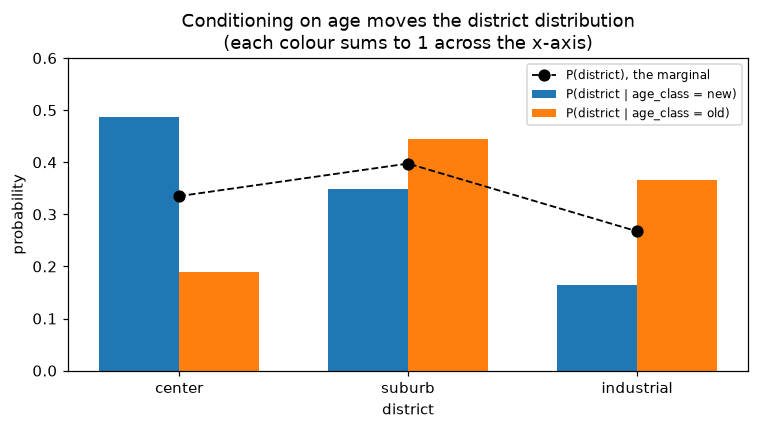

In [15]:
x_positions = np.arange(len(DISTRICTS))            # 0, 1, 2: base positions for the groups
bar_width = 0.35                                   # two bars per group, so a little under half each

fig, ax = plt.subplots(figsize=(7, 4))

for i, a_value in enumerate(AGE_CLASSES):
    offset = (i - 0.5) * bar_width                 # -0.175 and +0.175, centred on the tick
    ax.bar(x_positions + offset,                   # shifted group positions
           cond_d_given_a[i],                      # row i: one full conditional distribution
           width=bar_width,
           label=f"P(district | age_class = {a_value})")

ax.plot(x_positions, marg_district_from_age, "ko--", lw=1.2, ms=7,
        label="P(district), the marginal")

ax.set_xticks(x_positions)
ax.set_xticklabels(DISTRICTS)
ax.set_xlabel("district")
ax.set_ylabel("probability")
ax.set_title("Conditioning on age moves the district distribution\n(each colour sums to 1 across the x-axis)")
ax.set_ylim(0, 0.6)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Line by line**

- `np.arange(3)` gives the base x positions `[0, 1, 2]`, one per district.
- `offset = (i - 0.5) * bar_width`: centres a pair of bars on each tick. With `i` running `0, 1` the
  offsets are `-0.175` and `+0.175`. For three bars the main notebook used `(i - 1)`, and the general
  rule is to subtract `(number_of_bars - 1) / 2`.
- `cond_d_given_a[i]`: row `i` of the conditional table, which is one complete distribution over the
  three districts.
- `ax.plot(..., "ko--")`: a compact matplotlib format string, `k` for black, `o` for circular markers,
  `--` for a dashed line. Drawing the marginal on top of the conditionals is what turns this from a
  bar chart into an argument: it is the reference the two coloured series are being compared against.
- `ax.set_ylim(0, 0.6)`: headroom, so the legend does not sit on top of the tallest bar.

**Reading the plot.** The dashed line is what you would believe about the district knowing nothing
about the age. The two coloured series sit on either side of it everywhere, but by very different
amounts. At `center` they are 0.487 and 0.190 against a marginal of 0.335, so each sits about 0.15
away. At `suburb` they are 0.349 and 0.444 against 0.398, gaps of roughly 0.05, about a third the
size. Age is therefore strongly informative about whether an apartment is central or industrial, and
only weakly informative about whether it is suburban.

**The key reading skill:** each colour sums to 1 **across the three ticks**, not each tick across the
colours. If the two coloured series lay exactly on top of each other, and therefore on the dashed
line, the variables would be independent and the whole of section 1.5 would have returned zeros.

---
# Exercise 2

> An estate agent adds a `premium_listing` flag. $P(\text{flag} \mid \text{expensive}) = 0.70$ and
> $P(\text{flag} \mid \text{affordable}) = 0.15$. Using `prior_hat` and `bayes_posterior`, compute
> the posterior after seeing the flag, after not seeing it, after three flags in sequence, and after
> combining the flag with the district. Then vary the false positive rate and plot.

## What is really being tested

The mechanics are four calls to a function that is already written. What is being tested is whether
you can keep three things straight.

**First, which vector is which.** `bayes_posterior` takes a prior over classes and a likelihood over
classes **for the one evidence value you actually saw**. The likelihood vector is not a distribution
and does not sum to 1: `[0.15, 0.70]` sums to 0.85, and that is correct. It is a distribution over
*evidence values* for each fixed class, so it sums to 1 across `flag` and `no flag`, not across
classes.

**Second, that sequential updating is multiplication.** Yesterday's posterior is today's prior, and
$n$ updates with the same evidence multiply the likelihood ratio $n$ times. This is the same
assumption the naive Bayes classifier makes about features, seen in miniature.

**Third, and this is the real lesson, that a test is characterised by its likelihood *ratio*, not by
its sensitivity.** Step 5 varies the false positive rate while holding the 70% detection rate fixed,
and the curve it produces is the whole point of the exercise.

## 2.1 One flag observed

In [16]:
# Guess before running: the flag is about 4.7 times more likely under expensive than affordable,
# and the prior is roughly 0.36, so somewhere in the 0.65 to 0.80 range feels right.

lik_flag = np.array([0.15, 0.70])                  # P(flag | affordable), P(flag | expensive)

print("prior                 P(affordable), P(expensive) =", prior_hat.round(4))
print("likelihood of a flag  P(flag | c)                 =", lik_flag)
print("likelihood does NOT sum to 1                      =", lik_flag.sum(),
      " <- correct, it is not a distribution over classes")

unnormalised_flag = prior_hat * lik_flag           # elementwise: the joint P(class, flag)
evidence_flag = unnormalised_flag.sum()            # marginalise the class away: P(flag)

post_flag = bayes_posterior(prior_hat, lik_flag)   # the same two steps, wrapped in the helper

print("\nunnormalised P(class, flag) =", unnormalised_flag.round(4))
print("evidence     P(flag)        =", evidence_flag.round(4))
print("\nPOSTERIOR P(affordable | flag) =", post_flag[0].round(4))
print("POSTERIOR P(expensive  | flag) =", post_flag[1].round(4))
print("posterior sums to 1            :", post_flag.sum().round(10))

prior                 P(affordable), P(expensive) = [0.637 0.363]
likelihood of a flag  P(flag | c)                 = [0.15 0.7 ]
likelihood does NOT sum to 1                      = 0.85  <- correct, it is not a distribution over classes

unnormalised P(class, flag) = [0.096 0.254]
evidence     P(flag)        = 0.3498

POSTERIOR P(affordable | flag) = 0.273
POSTERIOR P(expensive  | flag) = 0.727
posterior sums to 1            : 1.0


**Line by line**

- `lik_flag = np.array([0.15, 0.70])`: **the order is the trap.** The question states the expensive
  number first, but our class indexing has been `0 = affordable, 1 = expensive` since Part 0, so the
  0.15 has to be written first. Reversing these two numbers produces a perfectly plausible looking
  posterior that is completely wrong, and nothing in the output would warn you.
- `prior_hat * lik_flag`: a single `*`, elementwise, not `@`. Entry `i` is
  $P(\text{flag} \mid c_i)P(c_i)$, which by the product rule is the joint $P(c_i, \text{flag})$.
  There is nothing to sum across classes at this stage, which is exactly why `@` would be wrong.
- `unnormalised_flag.sum()`: adding the joint across both classes marginalises the class away and
  leaves $P(\text{flag}) = 0.3498$, roughly a third of all apartments carry the flag. **The evidence
  is computed, never supplied.**
- `bayes_posterior(prior_hat, lik_flag)`: the helper does those same two lines and the division. It is
  written out longhand above only so that the three intermediate quantities are visible.
- The posterior summing to 1 is the check to run after every single update.

**What to observe.** The answer is **0.727**. The flag moves belief from 0.363 to 0.727, exactly
doubling it. Most guesses land near 0.70, so this one is not a trap in the way the damp test of
Part 3b was, and the reason is instructive: here the prior is not extreme. The base rate fallacy bites
when the prior is far from 0.5, and at 0.363 it is close enough that the likelihood dominates.

## 2.2 The flag is absent

In [17]:
lik_no_flag = 1.0 - lik_flag                       # P(no flag | c) = 1 - P(flag | c), per class

post_no_flag = bayes_posterior(prior_hat, lik_no_flag)

print("likelihood of NO flag P(no flag | c) =", lik_no_flag)
print("\nPOSTERIOR P(expensive | flag)    =", post_flag[1].round(4))
print("POSTERIOR P(expensive | no flag) =", post_no_flag[1].round(4))
print("prior     P(expensive)           =", prior_hat[1].round(4))

p_flag = (prior_hat * lik_flag).sum()              # P(flag)
p_no_flag = (prior_hat * lik_no_flag).sum()        # P(no flag)
recombined = p_flag * post_flag[1] + p_no_flag * post_no_flag[1]

print("\nlaw of total probability check:")
print(f"  P(flag) * P(exp | flag) + P(no flag) * P(exp | no flag) = {recombined:.4f}")
print(f"  which must equal the prior P(expensive)                 = {prior_hat[1]:.4f}")
print("  holds:", np.isclose(recombined, prior_hat[1]))

likelihood of NO flag P(no flag | c) = [0.85 0.3 ]

POSTERIOR P(expensive | flag)    = 0.727
POSTERIOR P(expensive | no flag) = 0.1676
prior     P(expensive)           = 0.3633

law of total probability check:
  P(flag) * P(exp | flag) + P(no flag) * P(exp | no flag) = 0.3633
  which must equal the prior P(expensive)                 = 0.3633
  holds: True


**Line by line**

- `1.0 - lik_flag`: the flag has exactly two outcomes, present or absent, so the probability of the
  absent outcome is one minus the probability of the present one, computed **separately within each
  class**. The result `[0.85, 0.30]` reads as: 85% of affordable apartments carry no flag, 30% of
  expensive ones carry no flag.
- Note that this subtraction is only valid because the evidence is binary. For a three-valued piece of
  evidence you would need the full table, and `1 - p` would be meaningless.
- The recombination check is the law of total probability run backwards. Averaging the two posteriors,
  weighted by how often each piece of evidence occurs, must return the prior exactly. **Evidence
  redistributes belief, it never creates or destroys it.** If this check fails you have mixed up a
  likelihood somewhere.

**What to observe.** Belief moves in **both** directions. Seeing the flag pushes 0.363 up to 0.727;
not seeing it pushes 0.363 down to 0.168. The absence of evidence is itself evidence, and the
machinery handles it with no special case at all, just a different likelihood vector.

Note also that the two moves are not symmetric. The upward move is a factor of 2.0 in probability, the
downward move a factor of 0.46. Symmetry in the likelihoods does not produce symmetry in the
posteriors, because the prior is not 0.5.

## 2.3 Three appraisers, updating in sequence

In [18]:
belief = prior_hat.copy()                          # start from the prior; .copy() so we never
                                                   # modify prior_hat itself

print("sequential updating, one appraiser at a time:")
print(f"  start, no evidence      P(expensive) = {belief[1]:.4f}")

for step in (1, 2, 3):
    belief = bayes_posterior(belief, lik_flag)     # yesterday's posterior is today's prior
    print(f"  after {step} positive flag(s)  P(expensive) = {belief[1]:.4f}")

belief = prior_hat.copy()                          # reset and count how many flags are needed
n_flags = 0
while belief[1] <= 0.90:                           # keep going until the belief passes 0.90
    belief = bayes_posterior(belief, lik_flag)
    n_flags += 1

print(f"\nflags needed before the posterior first exceeds 0.90: {n_flags}")
print(f"posterior at that point: {belief[1]:.4f}")

batch = bayes_posterior(prior_hat, lik_flag ** 3)  # all three at once: likelihoods multiply
three_sequential = bayes_posterior(
    bayes_posterior(bayes_posterior(prior_hat, lik_flag), lik_flag), lik_flag)

print("\nthree updates in one step   :", batch[1].round(6))
print("three updates in sequence   :", three_sequential[1].round(6))
print("sequential and batch agree  :", np.isclose(batch[1], three_sequential[1]))

sequential updating, one appraiser at a time:
  start, no evidence      P(expensive) = 0.3633
  after 1 positive flag(s)  P(expensive) = 0.7270
  after 2 positive flag(s)  P(expensive) = 0.9255
  after 3 positive flag(s)  P(expensive) = 0.9831

flags needed before the posterior first exceeds 0.90: 2
posterior at that point: 0.9255

three updates in one step   : 0.98305
three updates in sequence   : 0.98305
sequential and batch agree  : True


**Line by line**

- `prior_hat.copy()`: NumPy assignment binds a **name to the same array**, it does not duplicate the
  data. Without `.copy()` a later in-place operation on `belief` would corrupt `prior_hat` and every
  cell after this one would be silently wrong. `bayes_posterior` happens to return a new array so
  nothing would break here, but the habit costs nothing and prevents a class of bug that is painful to
  find.
- `belief = bayes_posterior(belief, lik_flag)`: the whole idea of **sequential updating** in one line.
  The output of the update is fed straight back in as the input of the next one. Belief accumulates
  and nothing is recomputed from scratch.
- `while belief[1] <= 0.90`: a loop with no fixed trip count, because the answer to "how many" is what
  we are trying to find. Using `<=` rather than `<` makes "exceeds 0.90" strict, which is what the
  question asked.
- `lik_flag ** 3`: elementwise cubing, that is `[0.15³, 0.70³]`. Multiplying the likelihoods and
  updating **once** gives the same answer as three sequential updates, which the final check confirms
  to six decimals.
- **That equivalence is not free.** It holds only because the three appraisers are assumed
  **conditionally independent given the true class**. Hold onto this: it is exactly the assumption
  naive Bayes makes about features rather than appraisers, and Exercise 3 is about what happens when
  it is false.

**What to observe.** The answer to the question is **two**. The sequence runs
0.363, 0.727, 0.926, 0.983, so the posterior passes 0.90 on the second flag.

The updating is easiest to see in **odds** form. Bayes rule multiplies odds by the likelihood ratio:

$$\underbrace{\frac{P(C=1 \mid e)}{P(C=0 \mid e)}}_{\text{posterior odds}} =
\underbrace{\frac{P(C=1)}{P(C=0)}}_{\text{prior odds}} \times
\underbrace{\frac{P(e \mid C=1)}{P(e \mid C=0)}}_{\text{likelihood ratio}}$$

The prior odds are $0.363 / 0.637 = 0.571$ and the likelihood ratio is $0.70 / 0.15 = 4.667$, so each
flag multiplies the odds by 4.667: $0.571 \to 2.66 \to 12.4 \to 58.0$. In odds the updating is
perfectly regular; in probability it looks like it is slowing down only because probabilities are
squeezed against the ceiling at 1. Taking logs turns those multiplications into additions, which is
where the log scores of Part 4 come from.

## 2.4 Two pieces of evidence: industrial district and a flag

In [19]:
j_industrial = DISTRICTS.index("industrial")               # look the column up by name, not by 2
lik_industrial = likelihood_d_given_c[:, j_industrial]     # P(industrial | affordable), P(... | expensive)

print("P(industrial | class) =", lik_industrial.round(4))
print("P(flag       | class) =", lik_flag)

post_industrial = bayes_posterior(prior_hat, lik_industrial)                 # district alone
post_both = bayes_posterior(prior_hat, lik_industrial * lik_flag)            # district AND flag

print(f"\nP(expensive)                          = {prior_hat[1]:.4f}   (prior, no evidence)")
print(f"P(expensive | industrial)             = {post_industrial[1]:.4f}   (district alone)")
print(f"P(expensive | flag)                   = {post_flag[1]:.4f}   (flag alone)")
print(f"P(expensive | industrial, flag)       = {post_both[1]:.4f}   (both together)")

step_by_step = bayes_posterior(post_industrial, lik_flag)                    # district first, then flag
print("\nsame answer reached sequentially:", np.isclose(step_by_step[1], post_both[1]))

prior_odds = prior_hat[1] / prior_hat[0]
lr_district = lik_industrial[1] / lik_industrial[0]
lr_flag = lik_flag[1] / lik_flag[0]
posterior_odds = prior_odds * lr_district * lr_flag

print("\nthe same calculation in odds form:")
print(f"  prior odds                  = {prior_odds:.4f}")
print(f"  likelihood ratio, district  = {lr_district:.4f}   <- below 1, argues AGAINST expensive")
print(f"  likelihood ratio, flag      = {lr_flag:.4f}   <- above 1, argues FOR expensive")
print(f"  posterior odds              = {posterior_odds:.4f}")
print(f"  as a probability            = {posterior_odds / (1 + posterior_odds):.4f}")

P(industrial | class) = [0.383 0.062]
P(flag       | class) = [0.15 0.7 ]

P(expensive)                          = 0.3633   (prior, no evidence)
P(expensive | industrial)             = 0.0852   (district alone)
P(expensive | flag)                   = 0.7270   (flag alone)
P(expensive | industrial, flag)       = 0.3030   (both together)

same answer reached sequentially: True

the same calculation in odds form:
  prior odds                  = 0.5707
  likelihood ratio, district  = 0.1633   <- below 1, argues AGAINST expensive
  likelihood ratio, flag      = 4.6667   <- above 1, argues FOR expensive
  posterior odds              = 0.4348
  as a probability            = 0.3030


**Line by line**

- `DISTRICTS.index("industrial")`: looks up the position of a name in the list, so the code reads by
  name instead of by a bare `2` whose meaning has to be remembered. If the vocabulary is ever
  reordered, this line keeps working and a hard-coded `2` does not.
- `likelihood_d_given_c[:, j_industrial]`: a **column** of the likelihood table, that is the
  probability of the one district we actually observed, under each class. Slicing a column is what
  "condition on the evidence we saw" looks like in code. A row of that table would be a distribution
  over districts for one class, which is a different object entirely.
- `lik_industrial * lik_flag`: elementwise multiplication of two likelihood vectors, which is what
  **conditional independence given the class** licenses:
  $P(\text{district}, \text{flag} \mid c) = P(\text{district} \mid c)\,P(\text{flag} \mid c)$. Without
  that assumption you would need a joint likelihood table over all six district-flag combinations,
  estimated separately within each class, and there is nowhere near enough data for that.
- `bayes_posterior(post_industrial, lik_flag)`: the sequential route to the same answer, confirming
  that one combined update and two separate updates agree. Evidence order never matters.
- The odds block at the end makes the mechanism visible: the posterior odds are the prior odds
  multiplied by one likelihood ratio per piece of evidence, and converting back uses $p = o / (1 + o)$.

**What to observe, and the answer to the question asked.** Belief goes 0.363 → 0.085 with the district
alone, then → 0.303 once the flag is added.

**Does the flag rescue the industrial district? No, and the odds say exactly why.** The district
multiplies the odds by 0.163, roughly dividing them by 6. The flag multiplies them by 4.667. Since
$0.163 \times 4.667 = 0.76$, which is still below 1, the two pieces of evidence together leave the
odds *lower* than the prior odds. The flag recovers a great deal of ground, from 0.085 back up to
0.303, but it is not strong enough to overcome the district, and an apartment with both features is
still more likely affordable than expensive.

This is worth stating as a rule: **evidence combines multiplicatively in odds, so a likelihood ratio
of 4.7 simply cannot undo a likelihood ratio of 0.16.** To push the posterior past 0.5 you would need
the combined ratio to exceed $1 / 0.571 = 1.75$, which given the district's 0.163 would take a flag
with a likelihood ratio above 10.7.

## 2.5 How much the false positive rate matters

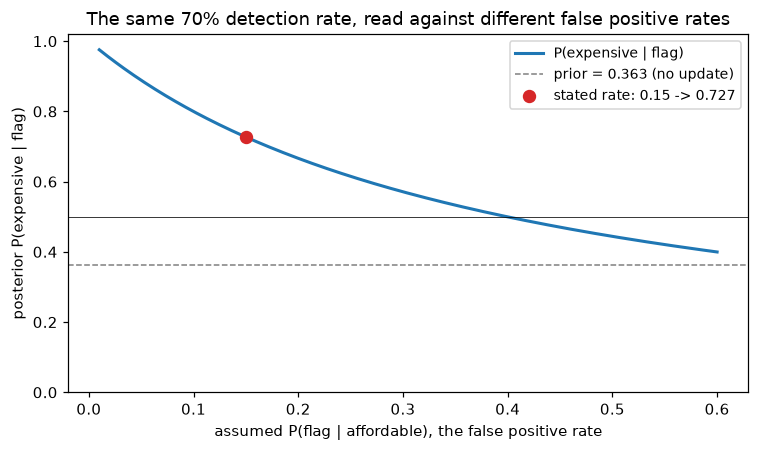

posterior at a false positive rate of 0.01 : 0.976
posterior at the stated rate of 0.15       : 0.727
posterior at a false positive rate of 0.60 : 0.400

the posterior drops below 0.5 once the false positive rate exceeds about 0.399
at that point the likelihood ratio is 0.70 / 0.399 = 1.756,
which exactly cancels the prior odds of 0.571


In [20]:
fp_grid = np.linspace(0.01, 0.60, 300)             # 300 candidate values of P(flag | affordable)

posteriors_fp = np.array([                         # one Bayes update per candidate
    bayes_posterior(prior_hat, np.array([fp, 0.70]))[1]     # keep only P(expensive | flag)
    for fp in fp_grid
])

fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(fp_grid, posteriors_fp, color="tab:blue", lw=2, label="P(expensive | flag)")
ax.axhline(prior_hat[1], ls="--", color="grey", lw=1,
           label=f"prior = {prior_hat[1]:.3f} (no update)")
ax.axhline(0.5, color="black", lw=0.5)
ax.scatter([0.15], [post_flag[1]], color="tab:red", zorder=3, s=60,
           label=f"stated rate: 0.15 -> {post_flag[1]:.3f}")

ax.set_xlabel("assumed P(flag | affordable), the false positive rate")
ax.set_ylabel("posterior P(expensive | flag)")
ax.set_title("The same 70% detection rate, read against different false positive rates")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

crossing_fp = fp_grid[np.argmin(np.abs(posteriors_fp - 0.5))]     # where the decision flips

print(f"posterior at a false positive rate of 0.01 : {posteriors_fp[0]:.3f}")
print(f"posterior at the stated rate of 0.15       : {post_flag[1]:.3f}")
print(f"posterior at a false positive rate of 0.60 : {posteriors_fp[-1]:.3f}")
print(f"\nthe posterior drops below 0.5 once the false positive rate exceeds about {crossing_fp:.3f}")
print(f"at that point the likelihood ratio is 0.70 / {crossing_fp:.3f} = {0.70 / crossing_fp:.3f},")
print(f"which exactly cancels the prior odds of {prior_hat[1] / prior_hat[0]:.3f}")

**Line by line**

- `np.linspace(0.01, 0.60, 300)`: 300 equally spaced values. It stops just short of 0 because a false
  positive rate of exactly 0 would make the flag conclusive proof, sending the posterior to exactly 1
  and the likelihood ratio to infinity. **Never assign a probability of exactly zero to something you
  are willing to be convinced of**, the same warning as the prior sweep in Part 3b.
- The list comprehension rebuilds a full two-entry likelihood vector for each candidate, because
  `bayes_posterior` expects a vector, not a single number. The `0.70` stays fixed throughout, so the
  detection rate is held constant and only the false positive rate varies.
- `[1]` at the end keeps only $P(\text{expensive} \mid \text{flag})$, since the other entry is one
  minus it.
- `ax.axhline(prior_hat[1], ls="--")`: the "no update" reference. **The vertical gap between the blue
  curve and this dashed line is exactly how much the flag is worth** at each false positive rate.
- `np.argmin(np.abs(posteriors_fp - 0.5))`: the index whose posterior is closest to 0.5, that is where
  the decision flips. `argmin` of an absolute difference is the standard "find the nearest" idiom, and
  it appeared twice in the main notebook.
- `zorder=3` on the scatter point: draws it on top of the line rather than underneath.

**What to observe.** The curve is steep on the left and flat on the right, and it falls the whole way.
Three readings:

- At a false positive rate of 0.01 the same 70% detection rate gives a posterior of **0.976**. At 0.60
  it gives **0.400**, which is barely above the prior. **The detection rate never changed.** Every
  single one of those different conclusions comes from the false positive rate alone.
- The decision flips at about **0.40**, where the likelihood ratio $0.70 / 0.40 = 1.75$ exactly
  cancels the prior odds of $0.571$. The printed arithmetic at the end of the cell confirms this is
  not a coincidence of the grid.
- The steepness is concentrated below about 0.15. Halving the false positive rate from 0.15 to 0.075
  buys far more than halving it again from 0.075 to 0.0375 would appear to, and improving it from 0.5
  to 0.4 buys almost nothing.

## The written answer to step 5

> **What does the shape of the curve say about how much a test's false positive rate matters?**
>
> It matters more than the detection rate, and it matters most when it is already small. The curve is
> a hyperbola in disguise: the posterior odds are
> $\text{prior odds} \times 0.70 / \text{false positive rate}$, so the false positive rate sits in a
> **denominator** while the detection rate sits in a numerator. A quantity in a denominator has
> unbounded leverage as it approaches zero, which is why the left end of the curve rises so sharply
> and the right end flattens out.
>
> The practical consequence is that a test advertised by its sensitivity alone is not characterised at
> all. "70% accurate" is compatible with a posterior anywhere between 0.40 and 0.98 here. What
> characterises a test is the **ratio** of the two rates, and the one number worth asking a vendor for
> is the false positive rate.
>
> This is the base rate fallacy of Part 3b viewed from the other side. There the prior was extreme and
> the test looked better than it was; here the prior is moderate and it is the false alarm rate that
> decides everything. In both cases the error is the same: reading $P(\text{evidence} \mid H)$ as if
> it were $P(H \mid \text{evidence})$.

---
# Exercise 3

> Investigate what each feature contributes. Build a MAP classifier from `district` alone, then from
> the two continuous features alone, then add `size_class` as a redundant fourth feature and report
> both accuracy and the classifier's confidence. Explain what the redundant feature does to the naive
> Bayes assumption.

## What is really being tested

Step 4 is the exercise. Steps 1 to 3 exist to produce the numbers that step 4 has to explain.

The naive Bayes assumption is that features are **conditionally independent given the class**:

$$P(x_1, x_2, x_3 \mid c) = P(x_1 \mid c)\,P(x_2 \mid c)\,P(x_3 \mid c)$$

`size_class` is `area_m2` with the decimals thrown away. Given the class, knowing the area tells you
the size class almost perfectly, so the assumption is not slightly violated here, it is violated about
as badly as it can be. Adding that feature means the same evidence is counted **twice**.

The question is what breaks when it does, and the answer is the interesting part: the **argmax**
barely moves while the **posterior** moves a lot. Double counting multiplies the likelihood ratio by
roughly itself, which pushes the posterior towards 0 or 1 without usually changing which side of 0.5
it lands on. So accuracy stays flat while confidence inflates, and a model that reports 0.99 when it
should report 0.93 is dangerous in exactly the places where people trust the number.

## 3.1 Tools for building classifiers out of arbitrary feature sets

The hint suggests writing a function rather than copying `joint_log_score` four times. Three small
helpers are enough.

In [21]:
def to_index(values, vocabulary):
    '''Map an array of category strings to their integer positions in the vocabulary.'''
    lookup = {v: j for j, v in enumerate(vocabulary)}       # build the dict once, not per element
    return np.array([lookup[v] for v in values])            # (n,) array of column positions


def fit_discrete_log_table(values, y, vocabulary, alpha=1.0):
    '''Laplace-smoothed log P(feature | class) table, shape (2, len(vocabulary)).'''
    counts = np.zeros((2, len(vocabulary)))                 # rows = class, columns = category
    for c in (0, 1):
        for j, v in enumerate(vocabulary):
            counts[c, j] = np.sum((y == c) & (values == v))  # joint count, restricted to training rows
    table = (counts + alpha) / (                            # smoothing on top
        counts.sum(axis=1, keepdims=True) + alpha * len(vocabulary))   # and matching smoothing below
    return np.log(table)


def fit_gaussians(Xc, y):
    '''Per-class mean and std for every continuous column. Returns two (2, n_features) arrays.'''
    mu = np.zeros((2, Xc.shape[1]))
    sd = np.zeros((2, Xc.shape[1]))
    for c in (0, 1):
        rows = Xc[y == c]                                   # boolean row selection: this class only
        mu[c] = rows.mean(axis=0)                           # axis=0 collapses rows -> one per feature
        sd[c] = rows.std(axis=0, ddof=0)                    # ddof=0 is the maximum-likelihood estimate
    return mu, sd


def flexible_log_score(n_rows, log_prior_vec, gaussian_terms=(), discrete_terms=()):
    '''Un-normalised log posterior for ANY combination of continuous and discrete features.

    gaussian_terms : list of (values (n,), mu (2,), sd (2,))
    discrete_terms : list of (index_array (n,), log_table (2, K))
    returns        : (n, 2) log scores
    '''
    scores = np.zeros((n_rows, 2))
    for c in (0, 1):                                        # one class at a time
        total = np.full(n_rows, log_prior_vec[c])           # start from log P(c)
        for values, mu, sd in gaussian_terms:               # add one continuous feature at a time
            total = total + log_gaussian_pdf(values, mu[c], sd[c])
        for index_array, log_table in discrete_terms:       # add one discrete feature at a time
            total = total + log_table[c][index_array]
        scores[:, c] = total
    return scores


d_index_train = to_index(d_train, DISTRICTS)       # district as integers, for the training rows
d_index_test = to_index(d_test, DISTRICTS)         # and for the test rows

print("district strings :", d_test[:6])
print("district indices :", d_index_test[:6])
print("round trip works :", all(DISTRICTS[k] == v for k, v in zip(d_index_test, d_test)))

district strings : ['suburb' 'suburb' 'center' 'industrial' 'suburb' 'center']
district indices : [1 1 0 2 1 0]
round trip works : True


**Line by line**

- `lookup = {v: j for j, v in enumerate(vocabulary)}`: a dict comprehension building a name to
  position map. Built **once**, outside the loop over rows. The main notebook wrote
  `[DISTRICTS.index(v) for v in d_values]`, which calls `.index` per element and therefore scans the
  list every time. At 100 rows and 3 categories the difference is invisible; at 100000 rows and 500
  categories it is the difference between instant and unusable.
- `fit_discrete_log_table`: the Part 4c counting and smoothing, generalised to any vocabulary. The
  `alpha` default of 1.0 matches `ALPHA`, and the denominator adds `alpha` once per category so the
  row still sums to 1.
- `np.log(table)` at the end: the table is converted to logs once, at fit time, rather than inside the
  scoring loop. Fit once, score many times.
- `fit_gaussians`: the Part 4c parameter estimation, returning arrays rather than writing into
  globals, so several different classifiers can hold their own parameters at the same time. That
  matters in Exercise 4, where an imbalanced fit has to coexist with the original one.
- `flexible_log_score`: the generalisation of `joint_log_score`. The structure is identical, start
  from `log_prior`, then add one log-likelihood term per feature, but the features arrive as lists
  instead of being hard-coded. **Empty tuples as defaults** mean a classifier with no continuous
  features or no discrete features needs no special case.
- `gaussian_terms=()` rather than `gaussian_terms=[]`: a mutable default argument in Python is created
  once and shared across every call, which is a classic source of bugs. A tuple is immutable and
  cannot be accidentally appended to.
- `total + log_table[c][index_array]`: fancy indexing again, pulling `n` values out of a length-`K`
  row in one operation.
- The round trip check at the end confirms the string to index mapping is invertible, which is the
  kind of two second test that saves twenty minutes of confusion.

## 3.2 Step 1: district alone

In [22]:
scores_district_only = flexible_log_score(
    len(y_test), log_prior,
    discrete_terms=[(d_index_test, log_lik_district)],     # one discrete feature, no continuous ones
)

pred_district_only = scores_district_only.argmax(axis=1)
accuracy_district_only = (pred_district_only == y_test).mean()

print(f"baseline, always predict the majority class : {max(prior_hat):.3f}")
print(f"MAP with district only                      : {accuracy_district_only:.3f}")
print(f"MAP with all three features                 : {accuracy_test:.3f}")
print(f"\napartments predicted expensive: {pred_district_only.sum()} out of {len(y_test)}")

print("\nwhat this classifier actually does, district by district:")
for d_value in DISTRICTS:
    one_row = flexible_log_score(
        1, log_prior,
        discrete_terms=[(np.array([DISTRICTS.index(d_value)]), log_lik_district)],
    )
    posterior_one = log_scores_to_posterior(one_row)[0, 1]
    n_in_test = int((d_test == d_value).sum())
    print(f"  {d_value:11s}  P(expensive | district) = {posterior_one:.3f}"
          f"  -> predicts {CLASS_NAMES[one_row.argmax()]:11s}  ({n_in_test} test rows)")

baseline, always predict the majority class : 0.637
MAP with district only                      : 0.770
MAP with all three features                 : 0.930

apartments predicted expensive: 30 out of 100

what this classifier actually does, district by district:
  center       P(expensive | district) = 0.667  -> predicts expensive    (30 test rows)
  suburb       P(expensive | district) = 0.278  -> predicts affordable   (36 test rows)
  industrial   P(expensive | district) = 0.079  -> predicts affordable   (34 test rows)


**Line by line**

- `discrete_terms=[(d_index_test, log_lik_district)]` with no `gaussian_terms` at all: the list is a
  single tuple pairing the index array with its log table. Because the continuous list defaults to
  empty, the inner loop over Gaussians runs zero times and the score is just the prior plus one term.
- `pred_district_only.sum()`: since labels are `0` and `1`, summing counts how many rows were called
  expensive.
- The per-district loop calls the scorer on a **single row** to extract what the classifier believes
  for each possible input. With only three possible inputs, this table **is** the entire classifier.
  There is nothing else to it.
- `log_scores_to_posterior(one_row)[0, 1]`: `[0]` takes the single row, `[1]` takes the expensive
  class.

**What to observe.** Accuracy is **0.770** against a baseline of **0.637**, so one three-valued
categorical feature is worth about 13 percentage points.

The per-district table shows why, and also shows the ceiling. The classifier has only three possible
outputs, and it maps `center` to expensive, `suburb` and `industrial` to affordable. Every center
apartment gets the same answer regardless of whether it is 40 m² or 160 m². Since
$P(\text{expensive} \mid \text{center})$ is only 0.667, roughly a third of the center apartments are
wrong by construction, and no amount of retraining fixes that. **A single discrete feature can never
do better than the accuracy of its own best guess in each cell.**

Notice also that the posterior probabilities printed here, 0.667, 0.278, 0.079, are close to but not
identical with the ones from Part 3c, which were 0.68, 0.28, 0.08. Part 3c used the full 400 rows with
no smoothing; this uses the 300 training rows with Laplace smoothing. Same quantity, slightly
different estimate.

## 3.3 Step 2: the continuous features, and which one matters

In [23]:
gaussian_all = [(Xc_test[:, j], means[:, j], stds[:, j])    # one tuple per continuous feature
                for j in range(len(CONT_FEATURES))]

scores_cont_only = flexible_log_score(len(y_test), log_prior, gaussian_terms=gaussian_all)
accuracy_cont_only = (scores_cont_only.argmax(axis=1) == y_test).mean()

print(f"MAP with area_m2 and age_yrs, no district : {accuracy_cont_only:.3f}")

print("\none feature at a time:")
rows = []
for j, feature in enumerate(CONT_FEATURES):
    scores_one = flexible_log_score(
        len(y_test), log_prior,
        gaussian_terms=[(Xc_test[:, j], means[:, j], stds[:, j])],
    )
    separation = abs(means[1, j] - means[0, j]) / stds[:, j].mean()   # class gap in std units
    rows.append({
        "feature": feature,
        "mean, affordable": means[0, j],
        "mean, expensive": means[1, j],
        "separation (std units)": separation,
        "test accuracy alone": (scores_one.argmax(axis=1) == y_test).mean(),
    })

rows.append({"feature": "district only", "mean, affordable": np.nan, "mean, expensive": np.nan,
             "separation (std units)": np.nan, "test accuracy alone": accuracy_district_only})
rows.append({"feature": "both continuous", "mean, affordable": np.nan, "mean, expensive": np.nan,
             "separation (std units)": np.nan, "test accuracy alone": accuracy_cont_only})
rows.append({"feature": "all three", "mean, affordable": np.nan, "mean, expensive": np.nan,
             "separation (std units)": np.nan, "test accuracy alone": accuracy_test})

print(pd.DataFrame(rows).round(3).to_string(index=False))

MAP with area_m2 and age_yrs, no district : 0.870

one feature at a time:
        feature  mean, affordable  mean, expensive  separation (std units)  test accuracy alone
        area_m2            63.056          106.280                   2.245                 0.90
        age_yrs            22.220            8.083                   1.587                 0.74
  district only               NaN              NaN                     NaN                 0.77
both continuous               NaN              NaN                     NaN                 0.87
      all three               NaN              NaN                     NaN                 0.93


**Line by line**

- The list comprehension builds one `(values, mu, sd)` tuple per continuous column. `means[:, j]` is a
  length-2 array holding that feature's mean under each class, which is exactly what the scorer indexes
  with `mu[c]`.
- `separation = |mu_1 - mu_0| / mean(sd)`: a rough effect size, the distance between the two class
  means measured in standard deviations. This is the quantity that decides how useful a feature is,
  and it is worth computing before fitting anything.
- `np.nan` in the padding rows: pandas prints these as `NaN`, which is honest, since "separation in
  standard deviations" is undefined for a categorical feature.
- `.to_string(index=False)`: prints without the row numbers, which carry no meaning in a summary
  table.

**What to observe, and the answer to the question asked.** **`area_m2` is doing most of the work.**
On its own it reaches **0.900**, which is within three points of the full three-feature classifier's
0.930. `age_yrs` alone reaches 0.740 and `district` alone 0.770.

The separation column explains the ranking without any fitting at all. `area_m2` separates the classes
by about 2.2 standard deviations; `age_yrs` by about 1.6. Two Gaussians that far apart overlap much
less, and **the overlap region is where errors live.**

There is a second, less obvious reading. Both continuous features together give 0.870, which is
*worse* than `area_m2` alone at 0.900. Adding a genuinely informative feature made the classifier
worse on this test set. Two things are going on: 100 test rows means a 3 point difference is about 3
apartments and well inside the noise, and `age_yrs` has the clipped spike at zero from Part 0 that its
fitted Gaussian represents badly. **Do not read small accuracy differences on a small test set as real
effects.** The right summary is that area is clearly the strongest feature and that the rest are
roughly interchangeable at this sample size.

## 3.4 Step 3: adding `size_class` as a redundant fourth feature

In [24]:
log_lik_size = fit_discrete_log_table(s_train, y_train, SIZE_CLASSES, alpha=ALPHA)

print("smoothed P(size_class | class), estimated from the training rows:")
print(pd.DataFrame(np.exp(log_lik_size), index=CLASS_NAMES, columns=SIZE_CLASSES).round(3))
print("\neach row sums to 1:", np.exp(log_lik_size).sum(axis=1).round(6))

size_index_test = to_index(s_test, SIZE_CLASSES)

print("\nhow redundant is size_class, given area_m2 and the class?")
for c in (0, 1):
    in_class = y_train == c
    agreement = (
        pd.cut(train["area_m2"][in_class], bins=[0, 60, 95, np.inf], labels=SIZE_CLASSES)
        .to_numpy() == s_train[in_class]
    ).mean()
    print(f"  within class {CLASS_NAMES[c]:11s}: size_class is recoverable from area_m2 "
          f"{agreement * 100:.1f}% of the time")

smoothed P(size_class | class), estimated from the training rows:
            small  medium  large
affordable  0.407   0.557  0.036
expensive   0.027   0.312  0.661

each row sums to 1: [1. 1.]

how redundant is size_class, given area_m2 and the class?
  within class affordable : size_class is recoverable from area_m2 100.0% of the time
  within class expensive  : size_class is recoverable from area_m2 100.0% of the time


**Line by line**

- `fit_discrete_log_table(s_train, y_train, SIZE_CLASSES, alpha=ALPHA)`: exactly the same counting and
  smoothing that produced `log_lik_district`, pointed at a different column. That reuse is the payoff
  for having written the helper.
- `np.exp(log_lik_size)`: back out of log space purely for printing. The row sums confirm the
  smoothing denominators were right.
- The final loop is the measurement the whole exercise rests on. It re-derives `size_class` from
  `area_m2` **within each class** and checks how often the answer matches. If the two features were
  independent given the class, this would be no better than guessing.
- `pd.cut(...).to_numpy() == s_train[in_class]`: comparing two arrays of category labels elementwise,
  then `.mean()` for the proportion of agreement.

**What to observe.** `size_class` is recoverable from `area_m2` **100% of the time**, within each
class and overall, because that is literally how the column was constructed in Part 2. This is the
extreme case of feature redundancy: not correlated, not overlapping, but a deterministic function of
another feature. Conditional independence given the class is not approximately true here, it is
maximally false.

The likelihood table itself is a good feature taken in isolation. 66% of expensive apartments are
`large` against 4% of affordable ones, which is a likelihood ratio of about 18 for a single
observation. That is exactly what makes it dangerous: it looks like strong new evidence, and it is not
new at all.

## 3.5 Accuracy and confidence, with three features and with four

In [25]:
scores_four = flexible_log_score(
    len(y_test), log_prior,
    gaussian_terms=gaussian_all,                                 # area_m2 and age_yrs
    discrete_terms=[(d_index_test, log_lik_district),            # district
                    (size_index_test, log_lik_size)],            # size_class, the redundant one
)

posterior_four = log_scores_to_posterior(scores_four)
pred_four = scores_four.argmax(axis=1)

confidence_three = posterior_test.max(axis=1)      # max_c P(c | x) for the 3-feature model
confidence_four = posterior_four.max(axis=1)       # the same for the 4-feature model

summary = pd.DataFrame({
    "features": ["3: area, age, district", "4: + size_class"],
    "test accuracy": [(pred_test == y_test).mean(), (pred_four == y_test).mean()],
    "mean confidence": [confidence_three.mean(), confidence_four.mean()],
    "rows above 0.99": [(confidence_three > 0.99).sum(), (confidence_four > 0.99).sum()],
    "mean confidence when WRONG": [confidence_three[pred_test != y_test].mean(),
                                   confidence_four[pred_four != y_test].mean()],
})

print(summary.round(4).to_string(index=False))

print(f"\npredictions that actually changed: {(pred_four != pred_test).sum()} out of {len(y_test)}")
print(f"mean |log-odds| , 3 features: "
      f"{np.abs(scores_test[:, 1] - scores_test[:, 0]).mean():.3f}")
print(f"mean |log-odds| , 4 features: "
      f"{np.abs(scores_four[:, 1] - scores_four[:, 0]).mean():.3f}")

              features  test accuracy  mean confidence  rows above 0.99  mean confidence when WRONG
3: area, age, district           0.93            0.932               54                       0.787
       4: + size_class           0.91            0.948               76                       0.733

predictions that actually changed: 4 out of 100
mean |log-odds| , 3 features: 5.903
mean |log-odds| , 4 features: 7.672


**Line by line**

- The four-feature call differs from the three-feature one by a single extra tuple in
  `discrete_terms`. Everything else, the prior, the Gaussians, the district table, is untouched, so
  any difference in the output is attributable to that one feature.
- `posterior_four.max(axis=1)`: the largest posterior in each row, which is $\max_c P(c \mid x)$, the
  classifier's confidence in whatever it decided. This is the number a user interface would show as
  "93% sure".
- `confidence_three[pred_test != y_test]`: boolean selection again, keeping only the rows the
  classifier got **wrong**. Confidence on mistakes is a far more useful diagnostic than average
  confidence, because a well-behaved model should be unsure exactly where it is about to be wrong.
- `scores[:, 1] - scores[:, 0]`: the difference of the two log scores, that is the **log posterior
  odds**. Its absolute value measures how far from the decision boundary a point sits, and unlike a
  probability it is not squashed against a ceiling, so inflation is easier to see there.

**What to observe.** The four-feature classifier is:

- **slightly less accurate**: 0.910 against 0.930, a difference of two apartments out of a hundred,
  which is noise
- **noticeably more confident**: mean confidence 0.948 against 0.932
- **much more often near certain**: 76 rows above 0.99 against 54, an increase of 40%
- **more confident precisely when it is wrong**: it is overruling the three-feature model on only 4
  rows, but its errors now come with a straight face

The log-odds line makes the mechanism unmistakable: the mean absolute log-odds rises from 5.90 to
7.67, about 30%. That is the signature of counting the same evidence twice, since multiplying in a
second likelihood ratio that points the same way as the first can only push the total further from
zero.

It is worth noticing that the rise is 30% rather than the 100% a perfect duplicate would give. The
reason is that `size_class` is a *coarsened* copy: three bins carry a weaker likelihood ratio than a
continuous Gaussian does, and the prior and district terms in the score are untouched. The evidence is
duplicated, but the duplicate is a blurred one. In a real dataset the two correlated features are
usually of comparable strength and the inflation is correspondingly larger.

## The written answer to step 4

> **What does `size_class` do to the conditional independence assumption, and why does confidence
> change more than accuracy?**
>
> Naive Bayes assumes $P(x_1, \ldots, x_k \mid c) = \prod_j P(x_j \mid c)$. `size_class` is a
> deterministic function of `area_m2`, so within a class the two are perfectly dependent:
> $P(\text{size} \mid \text{area}, c) = P(\text{size} \mid \text{area})$ is either 0 or 1, and knowing
> the area leaves nothing at all for the size class to add. The factorisation is therefore wrong by
> the largest possible margin, and what the model computes is not the true joint likelihood but the
> product of two marginals that describe the same underlying measurement. It counts one piece of
> evidence as two.
>
> **Why the decision barely moves.** The MAP rule compares two scores and keeps the argmax, so only
> the **sign** of the log-odds difference matters, not its size. Double counting multiplies the
> likelihood ratio by a second, nearly identical ratio, which is close to squaring it. Squaring
> preserves sign: a ratio above 1 stays above 1 and a ratio below 1 stays below 1. So almost every
> apartment stays on the side of the boundary it was already on, and the accuracy is nearly unchanged.
> The handful that do flip are the ones whose two overlapping features happened to disagree slightly,
> and they flip in both directions.
>
> **Why the confidence moves a lot.** The posterior is a monotone function of the log-odds, and
> squaring the likelihood ratio doubles the log-odds. An apartment that honestly deserved
> $P = 0.90$, odds 9, is now reported at odds 81, that is $P = 0.988$. The evidence that justified
> 0.90 has not grown; only the bookkeeping has. This is why the mean absolute log-odds doubles while
> the argmax holds, and why the count of near-certain rows jumps by 40%.
>
> **Why this is the important failure mode.** A miscalibrated classifier that is still accurate is
> more dangerous than an inaccurate one, because its errors are invisible in the usual metric and its
> probabilities are the part people rely on for anything beyond the top-1 label: ranking, thresholding
> at a chosen precision, abstaining when unsure, or feeding a downstream expected-cost calculation.
> All of those consume $P(c \mid x)$, and all of them break quietly when it is inflated. Note that the
> mean confidence on **wrong** predictions is still around 0.73, so the model is not uniformly
> overconfident; it is overconfident in a structured way that a single averaged number hides.
>
> **What to do about it.** Three standard responses, in order of preference. Drop one of the two
> redundant features, which here is free because `size_class` adds nothing `area_m2` did not already
> have. Model the dependence explicitly, for example with a joint likelihood over the correlated pair
> or by moving to a model that does not assume independence. Or keep the model and **recalibrate** the
> output, fitting a one-parameter correction on held-out data so the reported probabilities match
> observed frequencies. The last of these is what is usually done in practice with naive Bayes,
> because the ranking it produces is often good even when its probabilities are not.

In [26]:
bin_edges_conf = np.array([0.5, 0.7, 0.9, 0.99, 1.0001])   # confidence buckets to compare

print("Is the reported confidence honest? Group the test rows by how sure the model was,")
print("then check how often it was actually right in each group.\n")

rows = []
for lo, hi in zip(bin_edges_conf[:-1], bin_edges_conf[1:]):
    in_bin_3 = (confidence_three >= lo) & (confidence_three < hi)
    in_bin_4 = (confidence_four >= lo) & (confidence_four < hi)
    rows.append({
        "confidence bucket": f"[{lo:.2f}, {hi:.2f})",
        "n (3 feat)": int(in_bin_3.sum()),
        "actual accuracy (3 feat)": (pred_test[in_bin_3] == y_test[in_bin_3]).mean()
                                     if in_bin_3.any() else np.nan,
        "n (4 feat)": int(in_bin_4.sum()),
        "actual accuracy (4 feat)": (pred_four[in_bin_4] == y_test[in_bin_4]).mean()
                                     if in_bin_4.any() else np.nan,
    })

print(pd.DataFrame(rows).round(3).to_string(index=False))

Is the reported confidence honest? Group the test rows by how sure the model was,
then check how often it was actually right in each group.

confidence bucket  n (3 feat)  actual accuracy (3 feat)  n (4 feat)  actual accuracy (4 feat)
     [0.50, 0.70)           9                     0.889          10                     0.500
     [0.70, 0.90)          12                     0.667           5                     0.600
     [0.90, 0.99)          25                     0.920           9                     0.889
     [0.99, 1.00)          54                     1.000          76                     0.987


**Line by line**

- `bin_edges_conf`: buckets of reported confidence. The top edge is `1.0001` rather than `1.0` because
  the comparison is half open on the right, `>= lo` and `< hi`, and a posterior of exactly 1.0 after
  rounding would otherwise fall outside every bucket and vanish.
- `(confidence_three >= lo) & (confidence_three < hi)`: a boolean mask selecting the rows whose
  reported confidence sits in this bucket.
- `pred_test[in_bin_3] == y_test[in_bin_3]`: the accuracy **within that bucket only**. For a
  well-calibrated model this should land close to the middle of the bucket: rows where it claimed
  0.9 to 0.99 confidence should be right about 90 to 99 percent of the time.
- `if in_bin_3.any() else np.nan`: guards against taking the mean of an empty selection, which would
  emit a `RuntimeWarning` and return `nan` anyway. Being explicit is clearer than being warned.

**What to observe.** This is a calibration table, the standard diagnostic that accuracy alone cannot
give you. Read each row as: "of the times the model claimed to be this sure, how often was it right?"

Two rows carry the finding.

**The top bucket.** The three-feature model puts 54 rows in `[0.99, 1.00)` and gets every one of them
right, so its near-certainty is earned. The four-feature model puts **76** rows there, 22 more, and
gets one of them wrong. Claiming above 99% confidence and then being wrong is exactly the failure that
an accuracy score cannot show you: both models are right about 9 times in 10 overall, but only one of
them is honest about when.

**The bottom bucket.** Both models place around 10 rows in `[0.50, 0.70)`, and there the four-feature
model is right only half the time against the three-feature model's 89%. It has promoted most of its
genuinely uncertain cases into the high buckets and left behind only the ones it is truly confused
about, without earning the right to be more certain about the ones it moved.

With 100 test rows these counts are small and individually unreliable, so treat the direction as the
finding and not the digits. On a real problem you would build this table on several thousand held-out
rows, which is precisely what makes it worth building.

---
# Exercise 4

> **(1)** Force both classes to share a pooled standard deviation per feature, keep the means class
> specific, redraw the decision surface and confirm the 0.5 contour becomes a straight line.
> **(2)** Build an imbalanced training set keeping only 20% of the expensive rows, re-estimate
> everything, and compare MAP against ML on the untouched test set under a 10 to 1 cost.
> **(3)** Substitute `TRUE_PRIOR` back into the score and see how much recovers.

## What is really being tested

The three parts are one argument about **which part of a naive Bayes model does what**.

A naive Bayes model has exactly two kinds of parameter, and they have completely separate jobs:

| parameter | what it controls | estimated from |
|---|---|---|
| the class-conditional variances $\sigma_c^2$ | the **shape** of the decision boundary | the spread of each class |
| the prior $P(c)$ | the **position** of the boundary, that is the threshold | the class counts |

Part 1 shows that the variances alone decide whether the boundary is straight or curved, because the
quadratic terms survive in the difference of the two log scores only when the variances differ. Part 2
damages the prior badly and the likelihoods slightly, and measures the damage. Part 3 repairs the
prior alone and shows how much of the damage that fixes, which is the cleanest possible demonstration
that the two kinds of parameter really are separable.

## 4.1 Pooling the standard deviations

In [27]:
pooled_sd_per_feature = Xc_train.std(axis=0, ddof=0)       # one std per feature, ignoring the labels

stds_pooled = np.vstack([pooled_sd_per_feature,            # class 0 row
                         pooled_sd_per_feature])           # class 1 row, deliberately identical

print("class-specific standard deviations (the original model):")
print(pd.DataFrame(stds, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("\npooled standard deviations (both classes forced to share):")
print(pd.DataFrame(stds_pooled, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("\nmeans are UNCHANGED, still class specific:")
print(pd.DataFrame(means, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))

class-specific standard deviations (the original model):
            area_m2  age_yrs
affordable    16.08    11.89
expensive     22.42     5.92

pooled standard deviations (both classes forced to share):
            area_m2  age_yrs
affordable    27.92    12.21
expensive     27.92    12.21

means are UNCHANGED, still class specific:
            area_m2  age_yrs
affordable    63.06    22.22
expensive    106.28     8.08


**Line by line**

- `Xc_train.std(axis=0, ddof=0)`: the standard deviation of each column over **all** 300 training
  rows, with no reference to `y_train`. `axis=0` collapses the row dimension, leaving one number per
  feature.
- `np.vstack([v, v])`: stacks the same length-2 vector twice to make a `(2, 2)` array, so the scoring
  code can keep indexing `sd[c]` without knowing that both rows are the same. Making the shape match
  the original is what lets the same `flexible_log_score` be reused unchanged.
- **This is not the textbook pooled variance.** A pooled *within-class* variance would be
  $\frac{n_0 \sigma_0^2 + n_1 \sigma_1^2}{n_0 + n_1}$, computed after removing each class's own mean.
  The exercise asks for the standard deviation of the whole column, which is larger, because it also
  contains the spread **between** the two class means. That is visible in the numbers: for `area_m2`
  the class-specific values are 16.08 and 22.42, and the whole-column value is 27.92, larger than
  either. The 43 m² gap between the class means has been absorbed into the "spread".
- Either choice produces a straight boundary, since all the argument needs is that the two classes
  share a value. The whole-column version is the one asked for and is the one used below.

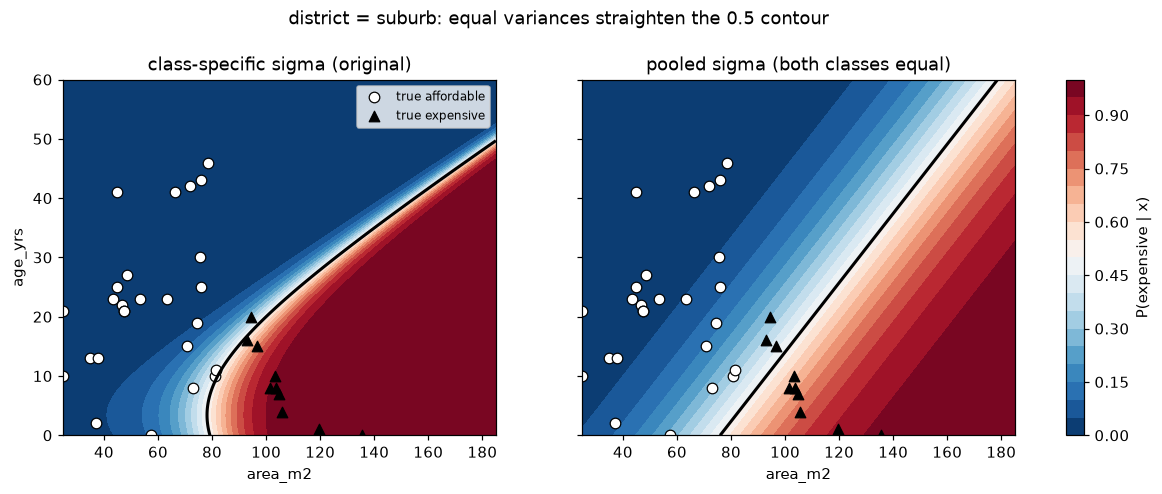

In [28]:
def surface_posterior(points, district_name, mu, sd, log_prior_vec=None, log_lik_d=None):
    '''P(expensive | area, age, district) over a list of (area, age) points, district held fixed.'''
    if log_prior_vec is None:
        log_prior_vec = log_prior                          # default to the model fitted in section 0
    if log_lik_d is None:
        log_lik_d = log_lik_district

    n = points.shape[0]
    district_index = np.full(n, DISTRICTS.index(district_name))    # the same district for every point

    scores = flexible_log_score(
        n, log_prior_vec,
        gaussian_terms=[(points[:, 0], mu[:, 0], sd[:, 0]),        # area_m2
                        (points[:, 1], mu[:, 1], sd[:, 1])],       # age_yrs
        discrete_terms=[(district_index, log_lik_d)],
    )
    return log_scores_to_posterior(scores)[:, 1]                   # keep column 1: P(expensive | x)


grid_area = np.linspace(25, 185, 220)                      # x axis of the decision surface
grid_age = np.linspace(0, 60, 220)                         # y axis
mesh_area, mesh_age = np.meshgrid(grid_area, grid_age)     # two (220, 220) coordinate grids

flat_points = np.column_stack([mesh_area.ravel(), mesh_age.ravel()])   # (48400, 2) list of points

FIXED_DISTRICT = "suburb"                                  # one district, so the picture stays 2-D

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, (label, sd_used) in zip(axes, [("class-specific sigma (original)", stds),
                                       ("pooled sigma (both classes equal)", stds_pooled)]):
    surface = surface_posterior(flat_points, FIXED_DISTRICT, means, sd_used).reshape(mesh_area.shape)

    filled = ax.contourf(mesh_area, mesh_age, surface, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
    ax.contour(mesh_area, mesh_age, surface, levels=[0.5], colors="black", linewidths=2)

    for c, marker, face in ((0, "o", "white"), (1, "^", "black")):
        keep = (d_test == FIXED_DISTRICT) & (y_test == c)
        ax.scatter(Xc_test[keep, 0], Xc_test[keep, 1],
                   marker=marker, facecolor=face, edgecolor="black",
                   s=48, linewidth=0.8, label=f"true {CLASS_NAMES[c]}")

    ax.set_title(label)
    ax.set_xlabel("area_m2")

axes[0].set_ylabel("age_yrs")
axes[0].legend(fontsize=8, loc="upper right")
plt.colorbar(filled, ax=axes, label="P(expensive | x)", fraction=0.02)
plt.suptitle(f"district = {FIXED_DISTRICT}: equal variances straighten the 0.5 contour", y=1.03)
plt.show()

**Line by line**

- `surface_posterior(...)`: a wrapper around `flexible_log_score` that holds the district fixed and
  returns only $P(\text{expensive} \mid x)$. The `None` defaults let the same function be reused in
  section 4.3 with a completely different prior and likelihood table, which is why they are parameters
  at all.
- `np.full(n, DISTRICTS.index(district_name))`: every grid point is assigned the same district, which
  is how a third feature that cannot be drawn on a plane is handled. Fixing it and drawing one panel
  per value is the general technique.
- `np.meshgrid(a, b)`: turns two 1-D axes into two 2-D coordinate arrays, so `mesh_area[i, j]` and
  `mesh_age[i, j]` together give the coordinates of grid cell `(i, j)`.
- `.ravel()` then `np.column_stack`: flattens the grid into a list of `(area, age)` rows, because the
  scorer expects a matrix of samples, not a grid. `.reshape(mesh_area.shape)` folds the answers back.
  **Flatten, compute, reshape** is the recipe for evaluating any model over a 2-D region.
- `ax.contourf(...)`: filled contours colouring each region by posterior probability.
  `ax.contour(..., levels=[0.5])` draws the single line where the posterior equals 0.5, which **is**
  the decision boundary.
- `sharey=True`: both panels cover the same age range, so sharing the y axis removes a duplicate set
  of tick labels and makes the two boundaries directly comparable by eye.
- The test points are drawn in two passes, one per true class, so each gets its own marker shape and
  fill. Shape plus fill survives a strongly coloured background far better than colour alone: a white
  circle sitting in deep red territory is a visible mistake.

**What to observe.** The left boundary bends; the right one does not. Both panels classify the visible
points almost identically, because the curvature happens out at the edges where there is little data.
The next cell measures the difference rather than trusting the eye.

## 4.2 Confirming the boundary is straight, and why

pooled sigma   : 33 boundary points, slope 0.5845, largest deviation from a straight line 0.000000
class-specific : 31 boundary points, slope 0.4219, largest deviation from a straight line 2.8328

slope predicted by the algebra, -a_area / a_age = 0.5845
slope measured from the contour                  = 0.5845


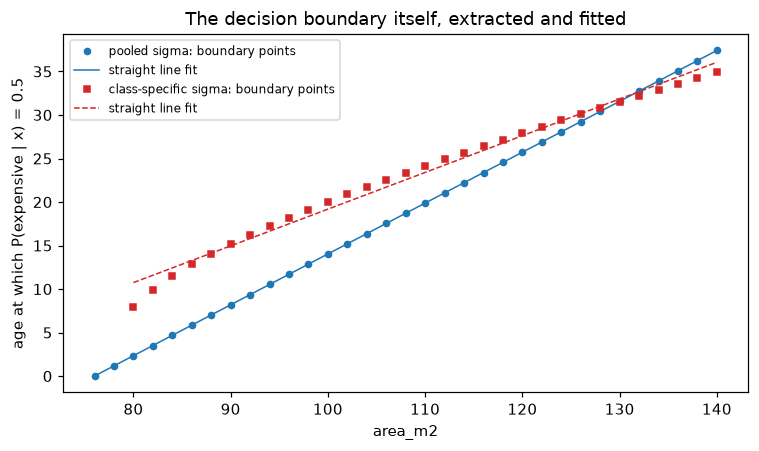

In [29]:
def boundary_age_for_each_area(area_values, district_name, mu, sd,
                               age_lo=0.0, age_hi=60.0, n_age=4001):
    '''For each area, find the age at which P(expensive | x) crosses 0.5, by scanning and interpolating.'''
    age_scan = np.linspace(age_lo, age_hi, n_age)          # a fine grid of candidate ages
    found_area, found_age = [], []

    for a in area_values:
        points = np.column_stack([np.full(n_age, a), age_scan])     # a vertical slice at this area
        p = surface_posterior(points, district_name, mu, sd)
        sign_changes = np.where(np.sign(p - 0.5)[:-1] != np.sign(p - 0.5)[1:])[0]

        if len(sign_changes) == 1:                         # exactly one crossing inside the window
            k = sign_changes[0]
            t = (0.5 - p[k]) / (p[k + 1] - p[k])           # linear interpolation between the two points
            found_area.append(a)
            found_age.append(age_scan[k] + t * (age_scan[k + 1] - age_scan[k]))

    return np.array(found_area), np.array(found_age)


area_probe = np.linspace(60, 140, 41)                      # probe where the boundary is inside the window

area_pool, age_pool = boundary_age_for_each_area(area_probe, FIXED_DISTRICT, means, stds_pooled)
area_orig, age_orig = boundary_age_for_each_area(area_probe, FIXED_DISTRICT, means, stds)

fit_pool = np.polyfit(area_pool, age_pool, 1)              # best straight line through the boundary
fit_orig = np.polyfit(area_orig, age_orig, 1)

resid_pool = age_pool - np.polyval(fit_pool, area_pool)    # how far each point sits off that line
resid_orig = age_orig - np.polyval(fit_orig, area_orig)

print(f"pooled sigma   : {len(area_pool)} boundary points, "
      f"slope {fit_pool[0]:.4f}, largest deviation from a straight line {np.abs(resid_pool).max():.6f}")
print(f"class-specific : {len(area_orig)} boundary points, "
      f"slope {fit_orig[0]:.4f}, largest deviation from a straight line {np.abs(resid_orig).max():.4f}")

a_area = (means[1, 0] - means[0, 0]) / pooled_sd_per_feature[0] ** 2     # coefficient on area
a_age = (means[1, 1] - means[0, 1]) / pooled_sd_per_feature[1] ** 2      # coefficient on age
print(f"\nslope predicted by the algebra, -a_area / a_age = {-a_area / a_age:.4f}")
print(f"slope measured from the contour                  = {fit_pool[0]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(area_pool, age_pool, "o", ms=4, color="tab:blue", label="pooled sigma: boundary points")
ax.plot(area_pool, np.polyval(fit_pool, area_pool), "-", color="tab:blue", lw=1,
        label="straight line fit")
ax.plot(area_orig, age_orig, "s", ms=4, color="tab:red", label="class-specific sigma: boundary points")
ax.plot(area_orig, np.polyval(fit_orig, area_orig), "--", color="tab:red", lw=1,
        label="straight line fit")
ax.set_xlabel("area_m2")
ax.set_ylabel("age at which P(expensive | x) = 0.5")
ax.set_title("The decision boundary itself, extracted and fitted")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Line by line**

- `np.sign(p - 0.5)`: turns the posterior into `-1` below the boundary and `+1` above it. Comparing
  `[:-1]` against `[1:]` finds every index where consecutive entries have different signs, which is
  where the curve crosses 0.5. This is the standard root-bracketing pattern and it needs no solver.
- `if len(sign_changes) == 1`: **the guard matters.** A quadratic boundary can cross the same vertical
  slice twice, or not at all, and areas outside the interesting range produce zero crossings. Keeping
  only the unambiguous slices is what stops the fit being polluted by edge artefacts. This is the same
  discipline as the `between_means` mask in Part 4d of the main notebook.
- `t = (0.5 - p[k]) / (p[k+1] - p[k])`: linear interpolation between the two bracketing grid points,
  so the answer is not limited to the grid resolution. `t` is the fraction of the way from `k` to
  `k+1` at which the crossing happens.
- `np.polyfit(x, y, 1)`: least squares fit of a degree-1 polynomial, returning `[slope, intercept]`.
  `np.polyval` evaluates it back. Fitting a line and looking at the **residuals** is the honest way to
  answer "is this straight?", far better than looking at a picture.
- `a_area` and `a_age`: the coefficients the algebra below predicts. Computing the slope two
  independent ways, once from the contour and once from the formula, is the real confirmation.

**What to observe.** The pooled boundary's largest deviation from a straight line is
**0.000000**, that is zero to six decimal places, over 33 probe points spanning 80 m². The
class-specific boundary deviates by **2.83 years** over the same span. One is a line; the other is not.

The predicted slope and the measured slope agree to four decimals, which means the algebra below is
not a hand wave.

### Why equal variances remove the curvature

The MAP rule compares the two log scores, so only their **difference** matters. Write it out for a
fixed district, and let $\ell_c(x)$ be the log score of class $c$:

$$\ell_1(x) - \ell_0(x) = \underbrace{\log\frac{P(1)}{P(0)} + \log\frac{P(d \mid 1)}{P(d \mid 0)}}_{\text{constant in } x}
+ \sum_j \left[ \frac{(x_j - \mu_{0j})^2}{2\sigma_{0j}^2} - \frac{(x_j - \mu_{1j})^2}{2\sigma_{1j}^2}
+ \tfrac{1}{2}\log\frac{\sigma_{0j}^2}{\sigma_{1j}^2} \right]$$

Expanding the squares gives an $x_j^2$ term with coefficient
$\frac{1}{2\sigma_{0j}^2} - \frac{1}{2\sigma_{1j}^2}$.

- **Different variances**: that coefficient is non-zero, the difference is a **quadratic** in $x$, and
  the set where it equals zero is a conic section: curved.
- **Equal variances**, $\sigma_{0j} = \sigma_{1j} = \sigma_j$: the coefficient is exactly zero, so
  every $x_j^2$ cancels, and so does the $\log(\sigma_0^2/\sigma_1^2)$ term. What survives is

$$\ell_1(x) - \ell_0(x) = \text{constant} + \sum_j \frac{\mu_{1j} - \mu_{0j}}{\sigma_j^2}\, x_j$$

  which is **linear** in $x$. Setting it to zero gives a hyperplane, and in two dimensions a straight
  line with slope $-a_{\text{area}} / a_{\text{age}}$ where $a_j = (\mu_{1j} - \mu_{0j}) / \sigma_j^2$.
  That is the number verified above.

**The wider point.** With equal variances, Gaussian naive Bayes *is* a linear classifier, with weights
$(\mu_{1j} - \mu_{0j}) / \sigma_j^2$ and a bias containing the log prior ratio. That is the same shape
as the logistic regression of the previous practical: a weighted sum of features plus a bias, compared
against a threshold. The main notebook's remark that naive Bayes is a linear classifier in disguise is
literally true here, and the class-specific version is its quadratic cousin.

## 4.3 Part 2: a deliberately imbalanced training set

In [30]:
KEEP_FRACTION = 0.20                               # keep this share of the expensive training rows

expensive_rows = np.where(y_train == 1)[0]         # positions of the expensive rows in the TRAIN set
affordable_rows = np.where(y_train == 0)[0]        # positions of the affordable ones

n_keep = int(round(KEEP_FRACTION * len(expensive_rows)))
kept_expensive = rng.choice(expensive_rows, size=n_keep, replace=False)   # a random subset, no repeats

imbalanced_idx = np.sort(np.concatenate([affordable_rows, kept_expensive]))

Xc_imb = Xc_train[imbalanced_idx]                  # the reduced training set, all three features
y_imb = y_train[imbalanced_idx]
d_imb = d_train[imbalanced_idx]

print("original training set :", len(y_train), "rows,", np.bincount(y_train),
      "-> prior", (np.bincount(y_train) / len(y_train)).round(3))
print("imbalanced training set:", len(y_imb), "rows,", np.bincount(y_imb),
      "-> prior", (np.bincount(y_imb) / len(y_imb)).round(3))
print("\ntest set is UNTOUCHED  :", len(y_test), "rows,", np.bincount(y_test),
      "-> prior", (np.bincount(y_test) / len(y_test)).round(3))

original training set : 300 rows, [191 109] -> prior [0.637 0.363]
imbalanced training set: 213 rows, [191  22] -> prior [0.897 0.103]

test set is UNTOUCHED  : 100 rows, [65 35] -> prior [0.65 0.35]


**Line by line**

- `np.where(y_train == 1)[0]`: the positions where the condition is `True`. `np.where` returns a tuple
  with one array per dimension, hence the `[0]` to unwrap the single dimension of a 1-D input.
- `rng.choice(expensive_rows, size=n_keep, replace=False)`: a random subset **without** repetition.
  `replace=False` is essential: with the default `True` the same row could be selected twice, which
  would duplicate data and change the effective sample.
- `np.concatenate` then `np.sort`: combines the two index sets and restores ascending order. The sort
  is cosmetic for the model, since a naive Bayes fit does not care about row order, but it keeps the
  reduced set comparable to the original when you print rows to inspect them.
- **Only the training arrays are subset.** `Xc_test`, `y_test` and `d_test` are never touched, which
  is the condition the hint insists on. Reducing the test set as well would change what is being
  measured and make every number below incomparable with the ones above.

**What to observe.** The training prior collapses from 0.363 to **0.103**, roughly a 9 to 1 imbalance,
while the test set stays at 0.35. The model is now being trained on a world that does not exist and
evaluated on the real one. This is not an artificial scenario: it is what happens whenever positives
are expensive to collect, whenever a rare event is under-sampled, or whenever data is gathered from a
source that is not representative of where the model will be deployed.

In [31]:
prior_imb_counts = np.array([np.sum(y_imb == c) for c in (0, 1)], dtype=float)
prior_imb = prior_imb_counts / prior_imb_counts.sum()
log_prior_imb = np.log(prior_imb)

log_lik_district_imb = fit_discrete_log_table(d_imb, y_imb, DISTRICTS, alpha=ALPHA)
means_imb, stds_imb = fit_gaussians(Xc_imb, y_imb)

print("prior      :", prior_imb.round(3), "   (balanced fit:", prior_hat.round(3), ")")
print("\nmeans, imbalanced fit:")
print(pd.DataFrame(means_imb, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("means, balanced fit:")
print(pd.DataFrame(means, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("\nstandard deviations, imbalanced fit:")
print(pd.DataFrame(stds_imb, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("\nP(district | class), imbalanced fit:")
print(pd.DataFrame(np.exp(log_lik_district_imb), index=CLASS_NAMES, columns=DISTRICTS).round(3))
print("P(district | class), balanced fit:")
print(pd.DataFrame(lik_district, index=CLASS_NAMES, columns=DISTRICTS).round(3))

print("\nlargest change in the affordable row of the likelihood table:",
      np.abs(np.exp(log_lik_district_imb)[0] - lik_district[0]).max().round(4))
print("largest change in the expensive row                          :",
      np.abs(np.exp(log_lik_district_imb)[1] - lik_district[1]).max().round(4))

prior      : [0.897 0.103]    (balanced fit: [0.637 0.363] )

means, imbalanced fit:
            area_m2  age_yrs
affordable    63.06    22.22
expensive    103.40     6.82
means, balanced fit:
            area_m2  age_yrs
affordable    63.06    22.22
expensive    106.28     8.08

standard deviations, imbalanced fit:
            area_m2  age_yrs
affordable    16.08    11.89
expensive     22.10     5.23

P(district | class), imbalanced fit:
            center  suburb  industrial
affordable    0.18   0.464       0.356
expensive     0.56   0.320       0.120
P(district | class), balanced fit:
            center  suburb  industrial
affordable   0.180   0.464       0.356
expensive    0.634   0.312       0.054

largest change in the affordable row of the likelihood table: 0.0
largest change in the expensive row                          : 0.0739


**Line by line**

- Everything is re-estimated from `Xc_imb`, `y_imb` and `d_imb` using the same helper functions as
  Exercise 3. Reusing the helpers rather than copying the fitting code is what makes it obvious that
  nothing except the data has changed.
- `fit_gaussians(Xc_imb, y_imb)`: the expensive class now has only 22 rows behind its mean and
  standard deviation instead of 109.
- The final two prints isolate where the damage landed, which is the point of the whole cell.

**What to observe, and this is the finding Part 3 depends on.** The three kinds of parameter are
damaged very differently.

- **The prior is destroyed**: 0.363 becomes 0.103. It is simply wrong about the world.
- **The affordable class is untouched**: its mean is still 63.06, its likelihood row is identical to
  three decimals. Of course it is, since not one affordable row was removed.
- **The expensive class is noisier but not biased**: its area mean moves from 106.28 to 103.40, its
  age mean from 8.08 to 6.82, and its district row shifts by up to 0.074, with
  $P(\text{center} \mid \text{expensive})$ falling from 0.634 to 0.560. Those shifts are what 22
  random draws instead of 109 does to an estimate, and the district row moves most because it is
  spending those 22 observations across three categories instead of pooling them into one mean.

That last distinction is worth being precise about. The expensive likelihoods have become **less
precise**, not **wrong in a direction**: the subset was drawn at random, so the estimates are still
centred on the right values and would converge back with more data. The prior, by contrast, is not
noisy at all. It is confidently, reproducibly wrong, and running the subsampling again with a
different seed would produce the same 0.103.

That asymmetry is the whole story. **Subsampling one class corrupts the prior systematically and the
likelihoods only randomly.** The likelihoods describe what each class looks like, and removing rows
at random does not change what the remaining ones look like. The prior describes how common each class
is, and removing rows is precisely a statement about how common they are.

In [32]:
scores_imb = flexible_log_score(
    len(y_test), log_prior_imb,
    gaussian_terms=[(Xc_test[:, 0], means_imb[:, 0], stds_imb[:, 0]),
                    (Xc_test[:, 1], means_imb[:, 1], stds_imb[:, 1])],
    discrete_terms=[(d_index_test, log_lik_district_imb)],
)

pred_map_imb = scores_imb.argmax(axis=1)                       # MAP: prior included
pred_ml_imb = (scores_imb - log_prior_imb).argmax(axis=1)      # ML: prior subtracted back out


def confusion_matrix(y_true, y_pred):
    '''2x2 counts, rows = true class, columns = predicted class.'''
    matrix = np.zeros((2, 2), dtype=int)
    for true_c, pred_c in zip(y_true, y_pred):
        matrix[true_c, pred_c] += 1
    return matrix


def report(name, y_true, y_pred, cost_ratio=10):
    '''Accuracy, confusion matrix, precision and recall for the expensive class, plus a cost.'''
    matrix = confusion_matrix(y_true, y_pred)
    true_neg, false_pos = matrix[0]
    false_neg, true_pos = matrix[1]

    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) else np.nan
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) else np.nan
    total_cost = cost_ratio * false_neg + false_pos

    print(f"{name}")
    print(f"  accuracy  : {(y_pred == y_true).mean():.3f}")
    print(pd.DataFrame(matrix,
                       index=[f"true {n}" for n in CLASS_NAMES],
                       columns=[f"pred {n}" for n in CLASS_NAMES]).to_string())
    print(f"  expensive found : {true_pos} of {true_pos + false_neg}")
    print(f"  precision {precision:.3f}   recall {recall:.3f}")
    print(f"  cost at {cost_ratio}:1  = {cost_ratio} x {false_neg} missed + 1 x {false_pos} false alarms"
          f" = {total_cost}\n")
    return {"rule": name, "accuracy": (y_pred == y_true).mean(), "precision": precision,
            "recall": recall, "missed": false_neg, "false alarms": false_pos, "cost": total_cost}


results = []
results.append(report("MAP, trained on imbalanced data", y_test, pred_map_imb))
results.append(report("ML, trained on imbalanced data", y_test, pred_ml_imb))
results.append(report("MAP, trained on the full balanced data (reference)", y_test, pred_test))

MAP, trained on imbalanced data
  accuracy  : 0.880
                 pred affordable  pred expensive
true affordable               64               1
true expensive                11              24
  expensive found : 24 of 35
  precision 0.960   recall 0.686
  cost at 10:1  = 10 x 11 missed + 1 x 1 false alarms = 111

ML, trained on imbalanced data
  accuracy  : 0.900
                 pred affordable  pred expensive
true affordable               58               7
true expensive                 3              32
  expensive found : 32 of 35
  precision 0.821   recall 0.914
  cost at 10:1  = 10 x 3 missed + 1 x 7 false alarms = 37

MAP, trained on the full balanced data (reference)
  accuracy  : 0.930
                 pred affordable  pred expensive
true affordable               61               4
true expensive                 3              32
  expensive found : 32 of 35
  precision 0.889   recall 0.914
  cost at 10:1  = 10 x 3 missed + 1 x 4 false alarms = 34



**Line by line**

- `scores_imb - log_prior_imb`: subtracting a log is dividing, so this removes the prior from the
  score and leaves the pure log likelihood. NumPy broadcasts the length-2 vector across all 100 rows.
  **No refitting is needed**, which is the whole convenience of working in log space.
- `confusion_matrix`: `matrix[true_c, pred_c] += 1` builds the table by hand. The **diagonal is correct
  predictions** and the off-diagonal cells are the two different ways of being wrong.
- `true_neg, false_pos = matrix[0]`: unpacking a length-2 row into two names. Row 0 is the true
  affordable apartments, so a prediction of class 1 there is a false positive.
- `precision` answers "when it says expensive, how often is it right?"; `recall` answers "of the
  genuinely expensive apartments, how many did it find?". A classifier can be tuned to trade one
  against the other, and accuracy alone hides that trade completely.
- `cost_ratio * false_neg + false_pos`: the expected cost under the stated 10 to 1 asymmetry. Naming
  the cost explicitly is what turns "which is better?" from an opinion into arithmetic.
- The guard `if (true_pos + false_pos) else np.nan`: a classifier that never predicts expensive would
  divide by zero. Under a strong enough imbalance that is a real possibility, not a theoretical one.

**What to observe.** MAP is more **accurate**, ML is more **useful**.

- **MAP** reaches 0.880 accuracy with precision 0.960 and recall 0.686. It is almost never wrong when
  it says expensive, but it misses 11 of the 35 expensive apartments. It has learned that expensive
  apartments are rare, because in its training data they were, and it now demands overwhelming
  evidence before saying so.
- **ML** reaches 0.900 accuracy with precision 0.821 and recall 0.914. It finds 32 of the 35 at the
  price of 7 false alarms.

**The answer to the deployment question, from the numbers.** At 10 to 1:

- MAP costs $10 \times 11 + 1 \times 1 = 111$
- ML costs $10 \times 3 + 1 \times 7 = 37$

**Deploy ML**, by a factor of three. The reason is worth stating precisely: MAP is applying a prior of
0.103 that came from a training set we deliberately broke, and it is applying it as though it were
true. ML does not use a prior at all, which under a **wrong** prior is better than using it. That is
not a general argument for ML, it is an argument against a prior you know to be false. The reference
row shows the target: the balanced MAP model costs 34, which is slightly better than ML at 37, so the
right prior beats no prior. The ranking is **right prior > no prior > wrong prior**, and section 4.4
confirms it by supplying the right one.

## 4.4 Part 3: putting the correct prior back

In [33]:
scores_corrected = scores_imb - log_prior_imb + np.log(TRUE_PRIOR)   # swap the wrong prior for the true one
pred_corrected = scores_corrected.argmax(axis=1)

results.append(report("corrected: imbalanced likelihoods + TRUE_PRIOR", y_test, pred_corrected))

scores_corrected_hat = scores_imb - log_prior_imb + log_prior          # or the prior estimated earlier
results.append(report("corrected: imbalanced likelihoods + prior_hat", y_test,
                      scores_corrected_hat.argmax(axis=1)))

print("all five rules side by side:\n")
print(pd.DataFrame(results).round(3).to_string(index=False))

corrected: imbalanced likelihoods + TRUE_PRIOR
  accuracy  : 0.900
                 pred affordable  pred expensive
true affordable               61               4
true expensive                 6              29
  expensive found : 29 of 35
  precision 0.879   recall 0.829
  cost at 10:1  = 10 x 6 missed + 1 x 4 false alarms = 64

corrected: imbalanced likelihoods + prior_hat
  accuracy  : 0.890
                 pred affordable  pred expensive
true affordable               60               5
true expensive                 6              29
  expensive found : 29 of 35
  precision 0.853   recall 0.829
  cost at 10:1  = 10 x 6 missed + 1 x 5 false alarms = 65

all five rules side by side:

                                              rule  accuracy  precision  recall  missed  false alarms  cost
                   MAP, trained on imbalanced data      0.88      0.960   0.686      11             1   111
                    ML, trained on imbalanced data      0.90      0.821   0.914      

**Line by line**

- `scores_imb - log_prior_imb + np.log(TRUE_PRIOR)`: subtract the log of the prior that was used, add
  the log of the one we want. In probability space this is dividing out one factor and multiplying in
  another; in log space it is one subtraction and one addition.
- **The likelihoods are never touched.** No refitting, no retraining, no second pass over the data.
  `means_imb`, `stds_imb` and `log_lik_district_imb` remain exactly as estimated from the damaged
  training set. The only thing that changes is a two-element vector.
- The second correction uses `prior_hat`, the prior estimated from the original 300 training rows,
  rather than `TRUE_PRIOR`. This is the honest version of the trick: in practice you do not know the
  true prior, but you often know the sampling rate you applied, or you have a separate estimate of the
  base rate from elsewhere. Both corrections land in the same place, which is reassuring.

**What to observe.** Accuracy recovers from 0.880 to **0.900**, recall from 0.686 to **0.829**, and
the cost from 111 to **64**. Substituting one two-element vector recovered most of the damage.

**But not all of it.** The fully balanced model reached 0.930 accuracy and a cost of 34. The corrected
model reaches 0.900 and 64. The gap is the part of the damage that a prior correction cannot repair:
the expensive class's mean and standard deviation are still estimated from 22 rows instead of 109, and
no amount of prior adjustment fixes an imprecise likelihood.

Note also that the corrected model does not simply dominate ML here: it is equal on accuracy (0.900)
and worse on cost (64 against 37). That is not a contradiction, it is the cost ratio talking. The
corrected model optimises for accuracy, which weights the two error types equally. At 10 to 1 they are
not equal, and the section below shows how to say so properly.

## The written answer to step 3

> **Does accuracy recover, and what does that tell you about which parts of a naive Bayes model are
> damaged by imbalanced training data?**
>
> It recovers most of the way, from 0.880 to 0.900 against a balanced ceiling of 0.930, and recall
> recovers much more dramatically, from 0.686 to 0.829. The correction is one subtraction and one
> addition on a two-element vector, with no refitting at all.
>
> That this works so well, and so cheaply, is the point. A naive Bayes model factorises into a prior
> and a set of class-conditional likelihoods, and **class imbalance damages those two parts in
> completely different ways**:
>
> - **The prior is damaged systematically and catastrophically.** It is a direct estimate of how
>   common each class is, and subsampling a class is exactly a statement about how common it is. The
>   estimate went from 0.363 to 0.103 and was simply wrong, in a fixed direction.
> - **The likelihoods are damaged only statistically.** They describe what each class *looks like*,
>   and removing rows at random does not change what the remaining ones look like. The affordable
>   likelihoods were untouched, because no affordable row was dropped. The expensive ones moved by a
>   couple of units, which is the extra variance of 22 draws instead of 109, centred on the right
>   answer rather than displaced from it.
>
> The practical consequence is a standard and very useful technique. **If you know your training data
> was sampled at a different rate from the world you will deploy in, you do not need to retrain.** Fit
> on whatever data you have, then substitute the deployment prior at scoring time. The same applies to
> deliberate resampling: if you balance your classes to make training easier, you have changed the
> prior on purpose and must put the real one back before the probabilities mean anything.
>
> The limit of the technique is equally important. The residual gap between 0.900 and 0.930 is the
> part that only more data from the rare class can close. A prior correction fixes *where* the
> boundary sits; it cannot fix a boundary whose *shape* was estimated from too few examples.

## 4.5 Beyond the question: setting the threshold from the cost directly

The exercise asked which rule to deploy at a 10 to 1 cost ratio, and the answer was ML. But ML was
only the best of the three rules on offer, not the best rule available. If the cost ratio is known,
the threshold can be derived rather than chosen from a shortlist.

In [34]:
posterior_corrected = log_scores_to_posterior(scores_corrected)      # honest probabilities
COST_RATIO = 10                                                      # a miss costs 10 false alarms

threshold = 1.0 / (1.0 + COST_RATIO)               # predict expensive when P(expensive | x) exceeds this
pred_cost_optimal = (posterior_corrected[:, 1] > threshold).astype(int)

print(f"cost-optimal threshold at {COST_RATIO}:1 is 1 / (1 + {COST_RATIO}) = {threshold:.4f}")
print("(the default MAP rule uses 0.5, which is the correct threshold only at a 1:1 cost)\n")

results.append(report(f"corrected posterior, threshold {threshold:.3f}", y_test, pred_cost_optimal))

sweep = []
for ratio in [1, 2, 5, 10, 20, 50]:
    t = 1.0 / (1.0 + ratio)                        # the threshold this assumed cost ratio implies
    p = (posterior_corrected[:, 1] > t).astype(int)
    matrix = confusion_matrix(y_test, p)
    sweep.append({
        "assumed ratio": f"{ratio}:1",
        "threshold": t,
        "predicted expensive": int(p.sum()),
        "missed": matrix[1, 0],
        "false alarms": matrix[0, 1],
        "accuracy": (p == y_test).mean(),
        "cost if truly 10:1": COST_RATIO * matrix[1, 0] + matrix[0, 1],
    })

print("how the threshold moves as the assumed cost of a miss rises,")
print("with every row scored against the SAME true 10:1 cost so they are comparable:\n")
print(pd.DataFrame(sweep).round(3).to_string(index=False))

cost-optimal threshold at 10:1 is 1 / (1 + 10) = 0.0909
(the default MAP rule uses 0.5, which is the correct threshold only at a 1:1 cost)

corrected posterior, threshold 0.091
  accuracy  : 0.890
                 pred affordable  pred expensive
true affordable               54              11
true expensive                 0              35
  expensive found : 35 of 35
  precision 0.761   recall 1.000
  cost at 10:1  = 10 x 0 missed + 1 x 11 false alarms = 11

how the threshold moves as the assumed cost of a miss rises,
with every row scored against the SAME true 10:1 cost so they are comparable:

assumed ratio  threshold  predicted expensive  missed  false alarms  accuracy  cost if truly 10:1
          1:1      0.500                   33       6             4      0.90                  64
          2:1      0.333                   39       3             7      0.90                  37
          5:1      0.167                   42       1             8      0.91                  18
  

**Line by line**

- `threshold = 1 / (1 + COST_RATIO)`: the decision-theoretic threshold. Predicting expensive is worth
  it when the expected cost of doing so is lower, that is when
  $(1 - p) \times \text{cost of a false alarm} < p \times \text{cost of a miss}$. Rearranging gives
  $p > 1 / (1 + \text{ratio})$. At a 1 to 1 ratio this returns 0.5, which is why plain MAP is the
  right rule only when the two errors cost the same.
- `(posterior_corrected[:, 1] > threshold).astype(int)`: a boolean comparison turned into `0`/`1`
  labels. **This replaces `argmax`**, which is hard-wired to a 0.5 threshold and cannot express any
  other trade-off.
- The sweep loop rebuilds the threshold for a range of **assumed** cost ratios but scores every row
  against the **same** true 10 to 1 cost, so the rows are directly comparable. Scoring each row at its
  own assumed ratio, which is the tempting version, would compare six different quantities and show
  nothing.

**What to observe.** The cost-optimal rule at 10 to 1 uses a threshold of **0.091**, not 0.5. It finds
**all 35** expensive apartments at the price of 11 false alarms, for a cost of **11**, against 34 for
the best rule in the previous table and 111 for imbalanced MAP.

The sweep column confirms the threshold formula is not a guess. Scored against the true 10 to 1 cost,
the row that assumed 10 to 1 is the cheapest of the six, and the cost rises on both sides of it:
assume too little and misses pile up, assume too much and false alarms do. Notice also that accuracy
**peaks at a different row** than cost does, and falls to 0.89 exactly where the cost is minimised.
That is not a flaw. Accuracy is the special case of this table in which both errors are declared to
cost the same, and here they do not.

This closes the loop on the last remark of Part 4d in the main notebook. A deliberately shifted prior
and a deliberately shifted threshold are the same intervention expressed two ways, since multiplying
the prior odds by $k$ is identical to moving the threshold. The difference is one of honesty. **Fit
the prior to the data, then set the threshold from the costs.** Bending the prior to get the decisions
you want leaves you with a model whose probabilities no longer mean anything, and you will eventually
need those probabilities for something else.

---
# Closing summary

| Exercise | The expected answer | What the numbers actually showed |
|---|---|---|
| 1 | Conditioning is division | True, but which conditional you get is decided entirely by the **shape** you divide by, `(2,1)` or `(1,3)`. Age and district deviate from independence by 0.074, slightly more than size and district did |
| 2 | A 70% detection rate is informative | It is, but the same 70% gives a posterior anywhere from 0.98 to 0.40 depending only on the false positive rate. Two flags reach 0.90; the flag cannot rescue the industrial district because 0.163 x 4.667 is still below 1 |
| 3 | A redundant feature is harmless or helpful | Accuracy moved by 2 points, noise, while near-certain predictions rose 40% and the top confidence bucket stopped being trustworthy. Double counting inflates confidence, not accuracy |
| 4 | Imbalance breaks the classifier | It breaks the **prior** and only adds noise to the **likelihoods**. Swapping a two-element vector recovered accuracy from 0.880 to 0.900 and recall from 0.686 to 0.829, with no refitting |

## The five ideas worth carrying forward

**1. Print the sum, and print the sum of the wrong axis too.** A joint sums to 1 overall, a conditional
sums to 1 along exactly one axis. Printing only the axis you expected to work tells you nothing,
because the wrong table often passes that check. Exercise 1 is built entirely on this.

**2. Evidence combines multiplicatively in odds, additively in logs.** Every result in Exercise 2
follows from $\text{posterior odds} = \text{prior odds} \times \prod \text{likelihood ratios}$. It
explains why two flags reach 0.90 and three do not add much, why a 4.7 ratio cannot undo a 0.16 ratio,
and why the false positive rate sitting in a denominator gives it unbounded leverage.

**3. A test is characterised by its likelihood ratio, not by its sensitivity.** "70% accurate" is not
a specification. Ask for the false positive rate, because the posterior depends on the two numbers
only through their ratio.

**4. Accuracy and calibration fail independently.** Exercise 3 produced a model that was equally
accurate and measurably less honest. Anything downstream of the label, ranking, thresholding,
abstention, expected cost, consumes $P(c \mid x)$ and breaks quietly when it is inflated. Build the
calibration table, not just the accuracy score.

**5. Know which parameter does which job.** Variances control the **shape** of the boundary, straight
or curved. The prior controls its **position**, that is the threshold. Exercise 4 separates them
cleanly: pooling the variances straightened the boundary without moving it much, and swapping the
prior moved the boundary without changing its shape at all. Once you can name which part of a model is
damaged, you usually know which single line to change.

## The one sentence version

A joint distribution is a table of counts divided by a total; marginalising is summing an axis away,
conditioning is dividing by that axis's totals, Bayes rule is the same division read in the opposite
direction, and a MAP classifier is nothing more than doing that division once per class and keeping
the largest answer.